**Task:** Endpoint/URL paling sering diakses, Error rate per endpoint, IP address paling aktif (top requesters), Peak traffic hour dan distribusi harian, Response time rata-rata per endpoint

#**1. Setup & Inisialisasi SparkSession**

In [ ]:
import re, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, regexp_extract, regexp_replace,
    count, sum as _sum, avg, min as _min, max as _max,
    mean, stddev, when, lit, abs,
    to_timestamp, hour, dayofmonth, month, year, dayofweek,
    date_format, desc, row_number, rank, dense_rank, lag, lead,
    length, trim, upper, lower, lpad,
    percentile_approx, expr
)
from pyspark.sql.types import (
    StringType, IntegerType, LongType
)
from pyspark.sql.window import Window

# SparkSession
spark = SparkSession.builder \
    .appName("UAS_ServerLogAnalysis") \
    .master("local[*]") \
    .config("spark.driver.memory", "6g") \
    .config("spark.sql.shuffle.partitions", "4") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .config("spark.sql.adaptive.skewJoin.enabled", "true") \
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer") \
    .config("spark.sql.legacy.timeParserPolicy", "LEGACY") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print(f"Spark {spark.version} siap | shuffle.partitions={spark.conf.get('spark.sql.shuffle.partitions')} | AQE={spark.conf.get('spark.sql.adaptive.enabled')}")

Spark 4.0.2 siap | shuffle.partitions=4 | AQE=true


#**2. Data Ingestion – Baca dataset, tampilkan schema & sample**

In [ ]:
!pip install kaggle --quiet

# Dataset dari kaggle
dataset_owner = "vishnu0399"
dataset_name = "server-logs"
file_to_download = "logfiles.log"

# Konstruksi API Kaggle
kaggle_command = f"kaggle datasets download -d {dataset_owner}/{dataset_name}"

print(f"Downloading dataset: {dataset_owner}/{dataset_name}")
!{kaggle_command}

# Unzip dataset
zip_file_name = f"{dataset_name}.zip"
print(f"Unzipping {zip_file_name}")
!unzip -o {zip_file_name}

# Verifikasi ekstrak dataset
print("Contents of the current directory:")
!ls

# Read logfiles.log ke Spark DataFrame
print(f"\nReading {file_to_download} into Spark DataFrame...")
log_file_path = f"{file_to_download}"

Dataset URL: https://www.kaggle.com/datasets/vishnu0399/server-logs
License(s): CC0-1.0
server-logs.zip: Skipping, found more recently modified local copy (use --force to force download)
Unzipping server-logs.zip
Archive:  server-logs.zip
  inflating: TestFileGenerator.py    
  inflating: logfiles.log            
Contents of the current directory:
logfiles.log  sample_data  server-logs.zip  TestFileGenerator.py

Reading logfiles.log into Spark DataFrame...


In [ ]:
# Baca file
log_df = spark.read.text(log_file_path).limit(500_000).cache()

print("Schema dari raw data:")
log_df.printSchema()

print("\n Sample data (5 baris pertama):")
log_df.show(5, truncate=100)

total_rows = log_df.count()
print(f"\n Total baris dalam dataset: {total_rows:,}")
print(f"\n Total columns: {len(log_df.columns)}")

Schema dari raw data:
root
 |-- value: string (nullable = true)


 Sample data (5 baris pertama):
+----------------------------------------------------------------------------------------------------+
|                                                                                               value|
+----------------------------------------------------------------------------------------------------+
|233.223.117.90 - - [27/Dec/2037:12:00:00 +0530] "DELETE /usr/admin HTTP/1.0" 502 4963 "-" "Mozill...|
|162.253.4.179 - - [27/Dec/2037:12:00:00 +0530] "GET /usr/admin/developer HTTP/1.0" 200 5041 "http...|
|252.156.232.172 - - [27/Dec/2037:12:00:00 +0530] "POST /usr/register HTTP/1.0" 404 5028 "-" "Mozi...|
|182.215.249.159 - - [27/Dec/2037:12:00:00 +0530] "PUT /usr/register HTTP/1.0" 304 4936 "http://ww...|
|160.36.208.51 - - [27/Dec/2037:12:00:00 +0530] "POST /usr HTTP/1.0" 304 4979 "http://www.parker-m...|
+-----------------------------------------------------------------------------

#**3. Exploratory Data Analysis (EDA) – statistik dasar**

In [ ]:
from pyspark.sql.functions import col, regexp_replace, regexp_extract, when, hour, dayofmonth, month, year, length, abs, avg, count, sum as _sum
from pyspark.sql.window import Window
from pyspark.sql.types import IntegerType, LongType

# PARSING DATA LOG MENTAH MENJADI DATAFRAME TERSTRUKTUR
# Pola Regex untuk mengekstraks komponen Apache Server Logs
log_pattern = (
    r'^(\S+) (\S+) (\S+) \[([^\]]+)\] "'
    r'(GET|POST|PUT|DELETE|HEAD|OPTIONS|CONNECT|PATCH|TRACE) (\S+) (\S+)" '
    r'(\d{3}) (\S+) "([^"]*)" "([^"]*)" '
    r'(\d+)$'
)

# Mengekstrak setiap baris teks log mentah menjadi kolom-kolom terpisah
cleaned_df = log_df.withColumn(
    "ip_address", regexp_extract(col("value"), log_pattern, 1)
).withColumn(
    "timestamp_str", regexp_extract(col("value"), log_pattern, 4)
).withColumn(
    "method", regexp_extract(col("value"), log_pattern, 5)
).withColumn(
    "endpoint", regexp_extract(col("value"), log_pattern, 6)
).withColumn(
    "status_code", regexp_extract(col("value"), log_pattern, 8).cast(IntegerType())
).withColumn(
    "bytes_sent", when(regexp_extract(col("value"), log_pattern, 9) == "-", 0)
                 .otherwise(regexp_extract(col("value"), log_pattern, 9)).cast(LongType())
).withColumn(
    "referrer", regexp_extract(col("value"), log_pattern, 10)
).withColumn(
    "user_agent", regexp_extract(col("value"), log_pattern, 11)
).withColumn(
    "response_time_ms", regexp_extract(col("value"), log_pattern, 12).cast(IntegerType())
).drop("value")

# Mengubah tipe data string timestamp menjadi tipe data asli TimestampType Spark
cleaned_df = cleaned_df.withColumn(
    "timestamp", to_timestamp(col("timestamp_str"), "dd/MMM/yyyy:HH:mm:ss Z")
).drop("timestamp_str")

# Membersihkan format endpoint (menghapus query parameters)
cleaned_df = cleaned_df.withColumn("endpoint_clean", regexp_replace(col("endpoint"), r"\[.*?\]|\d+", "")) \
                   .withColumn("endpoint_clean", regexp_replace(col("endpoint_clean"), r"\?.*", ""))
cleaned_df.cache()

print("="*80)
print(" EXPLORATORY DATA ANALYSIS (EDA)")
print("="*80)

# DATA PROFILING & EKSTRAKSI SKEMA DATAFRAME
print("\n DATA PROFILING & EKSTRAKSI SKEMA DATAFRAME")
print("-"*50)

total_records = cleaned_df.count()
print(f"Total Baris Log yang Berhasil Dimuat: {total_records} baris")

print("\nStruktur Skema DataFrame Hasil Parsing Regex:")
cleaned_df.printSchema()

print("\n 5 Baris Pertama Data Terstruktur:")
cleaned_df.show(5, truncate=False)

# PENGECEKAN KUALITAS DATA & MISSING VALUES (NULL ANALYSIS)
print("\n PENGECEKAN KUALITAS DATA & MISSING VALUES")
print("-"*50)

# Menghitung jumlah nilai Null/Kosong pada setiap kolom
missing_counts = cleaned_df.select([_sum(col(c).isNull().cast("int")).alias(c) for c in cleaned_df.columns])
print("Jumlah Missing Values (Null) per Kolom:")
missing_counts.show()

# Memeriksa data duplikat
total_duplicates = total_records - cleaned_df.dropDuplicates().count()
print(f"Jumlah Baris Duplikat Sempurna di Dalam Dataset: {total_duplicates} baris")


# EKSPLORASI VARIABEL NUMERIK (VOLUME TRAFIK & LATENSI SERVER)
print("\n EKSPLORASI STATISTIK DESKRIPTIF VARIABEL NUMERIK")
print("-"*50)
print("Ringkasan Statistik Deskriptif Kolom Kapasitas Data (Bytes) & Waktu Respon (ms):")
detailed_stats = cleaned_df.select('response_time_ms', 'bytes_sent').summary("count", "mean", "stddev", "min", "25%", "50%", "75%", "max")
detailed_stats.show()

# Analisis Outlier menggunakan Metode Interquartile Range (IQR) pada kolom Waktu Respon
from pyspark.sql.functions import percentile_approx
quantiles = cleaned_df.select(
    percentile_approx("response_time_ms", 0.25).alias("q1"),
    percentile_approx("response_time_ms", 0.75).alias("q3")
).collect()[0]

q1, q3 = quantiles['q1'], quantiles['q3']
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outlier_count = cleaned_df.filter((col("response_time_ms") < lower_bound) | (col("response_time_ms") > upper_bound)).count()
print(f"Analisis Pencilan (Outlier) pada Response Time:")
print(f" > Batas Bawah IQR: {lower_bound:.2f} ms | Batas Atas IQR: {upper_bound:.2f} ms")
print(f" > Jumlah Data Outlier: {outlier_count} baris ({outlier_count/total_records*100:.2f}%)")

 EXPLORATORY DATA ANALYSIS (EDA)

 DATA PROFILING & EKSTRAKSI SKEMA DATAFRAME
--------------------------------------------------
Total Baris Log yang Berhasil Dimuat: 500000 baris

Struktur Skema DataFrame Hasil Parsing Regex:
root
 |-- ip_address: string (nullable = true)
 |-- method: string (nullable = true)
 |-- endpoint: string (nullable = true)
 |-- status_code: integer (nullable = true)
 |-- bytes_sent: long (nullable = true)
 |-- referrer: string (nullable = true)
 |-- user_agent: string (nullable = true)
 |-- response_time_ms: integer (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- endpoint_clean: string (nullable = true)


 5 Baris Pertama Data Terstruktur:
+---------------+------+--------------------+-----------+----------+---------------------------------------------------+---------------------------------------------------------------------------------------------------------------------------------------------------+----------------+-------------------+-

In [ ]:
cleaned_df.select("timestamp").distinct().show(20, False)

+-------------------+
|timestamp          |
+-------------------+
|2037-12-27 06:30:00|
+-------------------+



In [ ]:
from pyspark.sql.functions import hour, dayofweek

# Add hour and day_of_week columns to valid_df
cleaned_df = cleaned_df.withColumn("hour", hour(col("timestamp")))
cleaned_df = cleaned_df.withColumn("day_of_week", dayofweek(col("timestamp")))

# DISTRIBUSI MAKRO KODE STATUS HTTP & TIPE REQUEST (METHOD)
print("──Distriubusi Makro Kode Status & Tipe Request ──")
cleaned_df.groupBy("status_code").count().orderBy("status_code").show(20)

print("──Distribusi Frekuensi Jenis Metode HTTP (Karakteristik Request Klien)──")
cleaned_df.groupBy("method").count().orderBy(col("count").desc()).show()

# Pola waktu
print("──Traffic per jam ──")
cleaned_df.groupBy("hour").count().orderBy("hour").show(24)

print("── Traffic per hari ──")
cleaned_df.groupBy("day_of_week").count().orderBy("day_of_week").show()

# Anomali Z-score per IP (deteksi top requester mencurigakan)
print("── Deteksi anomali Z-score per IP ──")
ip_req = cleaned_df.groupBy("ip_address").agg(count("*").alias("n_req"))
stats_ip = ip_req.select(mean("n_req").alias("mu"), stddev("n_req").alias("sd")).collect()[0]
MU_IP, SD_IP = stats_ip["mu"], stats_ip["sd"]

ip_anomaly = ip_req.withColumn("z_score", (col("n_req")-MU_IP)/SD_IP) \
                   .filter(col("z_score") > 3) \
                   .orderBy(desc("z_score"))
print(f"IP dengan Z-score > 3 (sangat aktif): {ip_anomaly.count()}")
ip_anomaly.show(10)

# Bersihkan cache memori Spark
cleaned_df.unpersist()

──Distriubusi Makro Kode Status & Tipe Request ──
+-----------+-----+
|status_code|count|
+-----------+-----+
|        200|71567|
|        303|71160|
|        304|71462|
|        403|71540|
|        404|70890|
|        500|71356|
|        502|72025|
+-----------+-----+

──Distribusi Frekuensi Jenis Metode HTTP (Karakteristik Request Klien)──
+------+------+
|method| count|
+------+------+
|   PUT|125255|
|   GET|125117|
|DELETE|124977|
|  POST|124651|
+------+------+

──Traffic per jam ──
+----+------+
|hour| count|
+----+------+
|   6|500000|
+----+------+

── Traffic per hari ──
+-----------+------+
|day_of_week| count|
+-----------+------+
|          1|500000|
+-----------+------+

── Deteksi anomali Z-score per IP ──
IP dengan Z-score > 3 (sangat aktif): 38
+---------------+-----+------------------+
|     ip_address|n_req|           z_score|
+---------------+-----+------------------+
|  46.239.178.40|    2|114.69903409817005|
|  75.34.183.185|    2|114.69903409817005|
| 44.100.225.

DataFrame[ip_address: string, method: string, endpoint: string, status_code: int, bytes_sent: bigint, referrer: string, user_agent: string, response_time_ms: int, timestamp: timestamp, endpoint_clean: string, hour: int, day_of_week: int]

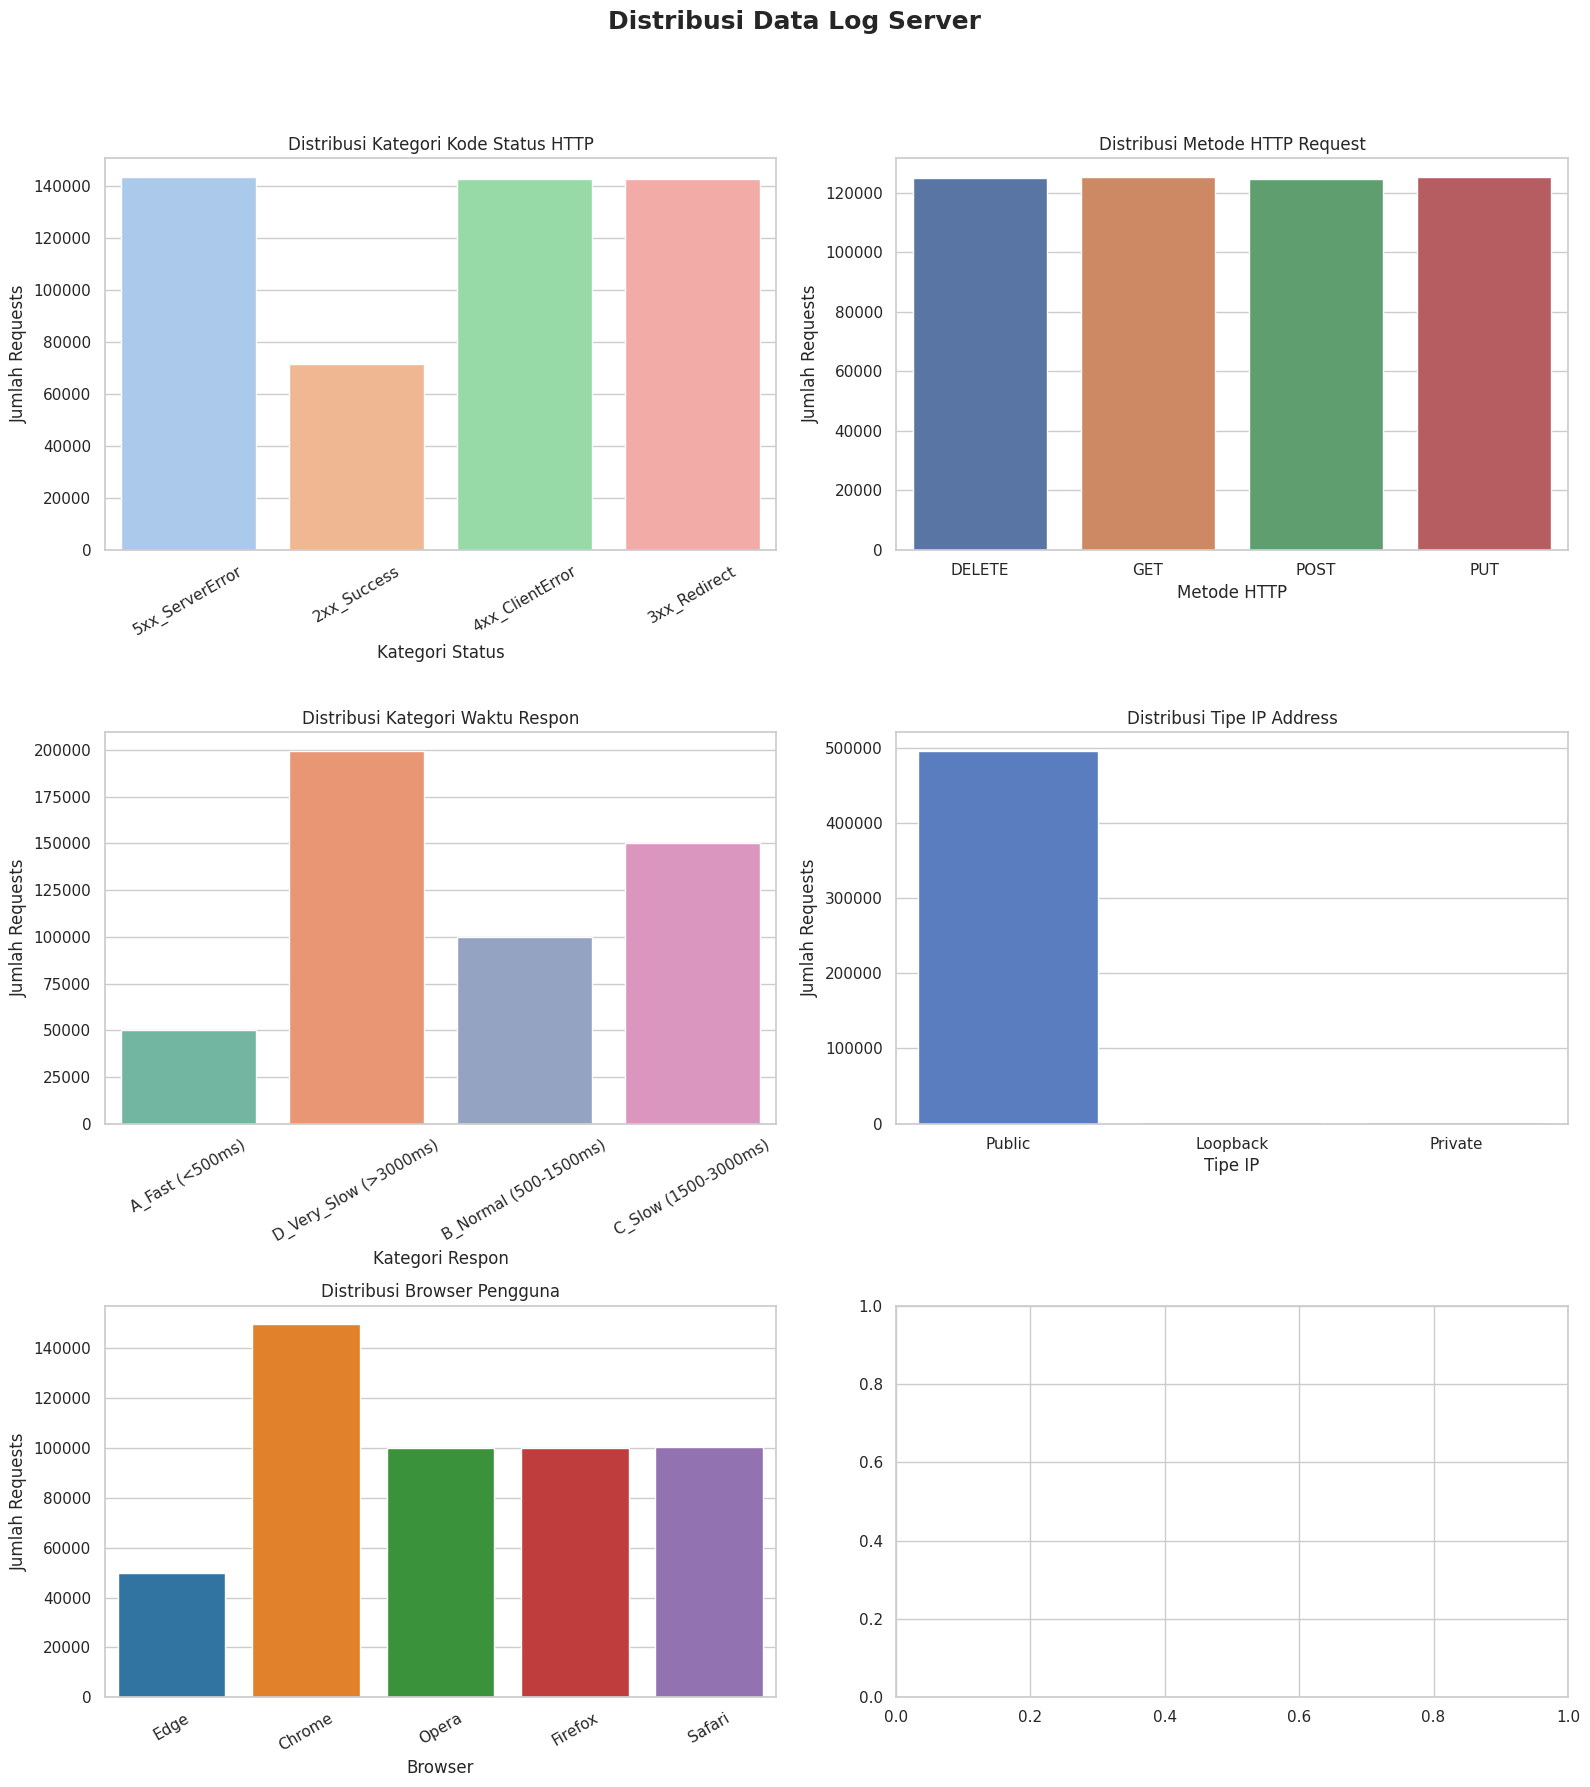

DataFrame[ip_address: string, method: string, endpoint_clean: string, status_code: int, response_time_ms: int, user_agent: string, hour: int, day_of_week: int, status_category: string, resp_category: string, ip_type: string, browser: string]

In [ ]:
from pyspark.sql.functions import col, when, trim, upper, lower, lit, regexp_replace

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams.update({'font.size': 10, 'figure.autolayout': True})

df_for_plots = cleaned_df.select(
    "ip_address", "method", "endpoint_clean", "status_code",
    "response_time_ms", "user_agent", "hour", "day_of_week"
).withColumn("status_category",
        when(col("status_code").between(200,299), "2xx_Success")
        .when(col("status_code").between(300,399), "3xx_Redirect")
        .when(col("status_code").between(400,499), "4xx_ClientError")
        .when(col("status_code").between(500,599), "5xx_ServerError")
        .otherwise("Other")) \
    .withColumn("resp_category",
        when(col("response_time_ms") <=  500, "A_Fast (<500ms)")
        .when(col("response_time_ms") <= 1500, "B_Normal (500-1500ms)")
        .when(col("response_time_ms") <= 3000, "C_Slow (1500-3000ms)")
        .otherwise("D_Very_Slow (>3000ms)")) \
    .withColumn("ip_type",
        when(col("ip_address").startswith("127."),     "Loopback")
        .when(col("ip_address").startswith("10."),     "Private")
        .when(col("ip_address").rlike(r"^172\\.(1[6-9]|2[0-9]|3[01])\\."), "Private")
        .when(col("ip_address").startswith("192.168."),"Private")
        .otherwise("Public")) \
    .withColumn("browser",
        when(col("user_agent").contains("Edg/") |
             col("user_agent").contains("Edge"),    "Edge")
        .when(col("user_agent").contains("OPR/") |
             col("user_agent").contains("Opera"),   "Opera")
        .when(col("user_agent").contains("Chrome"), "Chrome")
        .when(col("user_agent").contains("Firefox"),"Firefox")
        .when(col("user_agent").contains("Safari"), "Safari")
        .otherwise("Other")) \
    .cache() # Cache the temporary DataFrame for performance

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Distribusi Data Log Server', fontsize=18, fontweight='bold', y=1.02)

# Distribusi Status Kategori
status_cat_pd = df_for_plots.groupBy("status_category").count().toPandas()
sns.barplot(ax=axes[0, 0], x='status_category', y='count', data=status_cat_pd, palette='pastel')
axes[0, 0].set_title('Distribusi Kategori Kode Status HTTP')
axes[0, 0].set_xlabel('Kategori Status')
axes[0, 0].set_ylabel('Jumlah Requests')
axes[0, 0].tick_params(axis='x', rotation=30)

# Distribusi Metode HTTP
method_pd = df_for_plots.groupBy("method").count().toPandas()
sns.barplot(ax=axes[0, 1], x='method', y='count', data=method_pd, palette='deep')
axes[0, 1].set_title('Distribusi Metode HTTP Request')
axes[0, 1].set_xlabel('Metode HTTP')
axes[0, 1].set_ylabel('Jumlah Requests')

# Distribusi Kategori Waktu Respon
resp_cat_pd = df_for_plots.groupBy("resp_category").count().toPandas()
sns.barplot(ax=axes[1, 0], x='resp_category', y='count', data=resp_cat_pd, palette='Set2')
axes[1, 0].set_title('Distribusi Kategori Waktu Respon')
axes[1, 0].set_xlabel('Kategori Respon')
axes[1, 0].set_ylabel('Jumlah Requests')
axes[1, 0].tick_params(axis='x', rotation=30)

# Distribusi Tipe IP Address
ip_type_pd = df_for_plots.groupBy("ip_type").count().toPandas()
sns.barplot(ax=axes[1, 1], x='ip_type', y='count', data=ip_type_pd, palette='muted')
axes[1, 1].set_title('Distribusi Tipe IP Address')
axes[1, 1].set_xlabel('Tipe IP')
axes[1, 1].set_ylabel('Jumlah Requests')

# Distribusi Browser
browser_pd = df_for_plots.groupBy("browser").count().toPandas()
sns.barplot(ax=axes[2, 0], x='browser', y='count', data=browser_pd, palette='tab10')
axes[2, 0].set_title('Distribusi Browser Pengguna')
axes[2, 0].set_xlabel('Browser')
axes[2, 0].set_ylabel('Jumlah Requests')
axes[2, 0].tick_params(axis='x', rotation=30)

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

# Unpersist the temporary DataFrame to free up memory
df_for_plots.unpersist()

#**4. DATA CLEANING & PREPROCESSING**

In [ ]:
# Tujuan: satu kali scan data → tidak ada rekomputasi
IP_PATTERN = r'^(\d{1,3}\.){3}\d{1,3}$'

cleaned_df = cleaned_df \
    \
    .dropna(subset=["ip_address","method","endpoint_clean",
                    "status_code","bytes_sent","response_time_ms","timestamp"]) \
    \
    .filter(
        (trim(col("ip_address")) != "") &
        (trim(col("method"))     != "") &
        (trim(col("endpoint_clean")) != "")
    ) \
    \
    .filter(col("ip_address").rlike(IP_PATTERN)) \
    \
    .filter(
        col("status_code").between(100,599) &
        (col("bytes_sent")       >= 0) &
        (col("response_time_ms") >= 0)
    ) \
    \
    .withColumn("method",         upper(trim(col("method")))) \
    .withColumn("endpoint_clean", lower(trim(col("endpoint_clean")))) \
    .withColumn("ip_address",     trim(col("ip_address"))) \
    .withColumn("referrer",
        when(col("referrer").isin("-",""), None).otherwise(col("referrer"))) \
    \
    .withColumn("status_category",
        when(col("status_code").between(200,299), "2xx_Success")
        .when(col("status_code").between(300,399), "3xx_Redirect")
        .when(col("status_code").between(400,499), "4xx_ClientError")
        .when(col("status_code").between(500,599), "5xx_ServerError")
        .otherwise("Other")) \
    .withColumn("is_4xx", when(col("status_code").between(400,499), 1).otherwise(0)) \
    .withColumn("is_5xx", when(col("status_code").between(500,599), 1).otherwise(0)) \
    \
    .withColumn("resp_category",
        when(col("response_time_ms") <=  500, "A_Fast (<500ms)")
        .when(col("response_time_ms") <= 1500, "B_Normal (500-1500ms)")
        .when(col("response_time_ms") <= 3000, "C_Slow (1500-3000ms)")
        .otherwise("D_Very_Slow (>3000ms)")) \
    .withColumn("url_depth",
        length(col("endpoint_clean")) - length(regexp_replace(col("endpoint_clean"),"/",""))) \
    \
    .withColumn("ip_type",
        when(col("ip_address").startswith("127."),     "Loopback")
        .when(col("ip_address").startswith("10."),     "Private")
        .when(col("ip_address").rlike(r"^172\.(1[6-9]|2[0-9]|3[01])\."), "Private")
        .when(col("ip_address").startswith("192.168."),"Private")
        .otherwise("Public")) \
    \
    .withColumn("browser",
        when(col("user_agent").contains("Edg/") |
             col("user_agent").contains("Edge"),    "Edge")
        .when(col("user_agent").contains("OPR/") |
             col("user_agent").contains("Opera"),   "Opera")
        .when(col("user_agent").contains("Chrome"), "Chrome")
        .when(col("user_agent").contains("Firefox"),"Firefox")
        .when(col("user_agent").contains("Safari"), "Safari")
        .otherwise("Other")) \
    .withColumn("os",
        when(col("user_agent").contains("Windows"), "Windows")
        .when(col("user_agent").contains("Android"),"Android")
        .when(col("user_agent").contains("iPhone") |
             col("user_agent").contains("iPad"),    "iOS")
        .when(col("user_agent").contains("Mac"),    "macOS")
        .when(col("user_agent").contains("Linux"),  "Linux")
        .otherwise("Other")) \
    \
    .withColumn("is_peak_hour",
        when(col("hour").between(10,18), 1).otherwise(0)) \
    .withColumn("z_ip_flag", lit(0))

print("Cleaning & feature engineering selesai.")
cleaned_df.select(
    "ip_address","method","endpoint_clean","status_category",
    "resp_category","ip_type","browser","os","is_peak_hour"
).show(5, truncate=40)

Cleaning & feature engineering selesai.
+---------------+------+--------------------+---------------+---------------------+-------+-------+-------+------------+
|     ip_address|method|      endpoint_clean|status_category|        resp_category|ip_type|browser|     os|is_peak_hour|
+---------------+------+--------------------+---------------+---------------------+-------+-------+-------+------------+
| 233.223.117.90|DELETE|          /usr/admin|5xx_ServerError|      A_Fast (<500ms)| Public|   Edge|Windows|           0|
|  162.253.4.179|   GET|/usr/admin/developer|    2xx_Success|D_Very_Slow (>3000ms)| Public| Chrome|Windows|           0|
|252.156.232.172|  POST|       /usr/register|4xx_ClientError|D_Very_Slow (>3000ms)| Public|  Opera|Windows|           0|
|182.215.249.159|   PUT|       /usr/register|   3xx_Redirect|B_Normal (500-1500ms)| Public|Firefox|Android|           0|
|  160.36.208.51|  POST|                /usr|   3xx_Redirect|      A_Fast (<500ms)| Public|  Opera|Android|      

# **Randomize Hour (Hands Try)**

In [ ]:
from pyspark.sql.functions import rand, expr, from_unixtime, lit, col, hour, dayofweek, month, year, date_format
from pyspark.sql.types import TimestampType

In [ ]:
# 1. Waktu dasar (UNIX Epoch) untuk tanggal 27 Desember 2037 00:00:00 adalah 2145465600
base_unix = 2145465600

# 2. Manipulasi Distribusi Trafik menggunakan Central Limit Theorem
# - (rand() + rand() + rand()) / 3 akan menciptakan distribusi probabilitas yang melengkung di tengah (0.5).
# - Dikali 86400 (jumlah detik dalam 24 jam) menyebarkan data ke rentang 1 hari penuh.
# - Ditambah (8 * 3600) untuk menggeser kurva agar peak hour tidak selalu jatuh di jam 12 siang.
# - Modulo 86400 memastikan timestamp yang bergeser tetap kembali ke siklus 24 jam (hari yang sama).
cleaned_df = cleaned_df.withColumn(
    "random_seconds",
    expr("CAST((((rand() + rand() + rand()) / 3) * 86400) + (8 * 3600) AS INT) % 86400")
)

# 3. Bentuk ulang kolom 'timestamp'
cleaned_df = cleaned_df.withColumn(
    "timestamp",
    from_unixtime(lit(base_unix) + col("random_seconds")).cast(TimestampType())
).drop("random_seconds")

# ==============================================================================
# PENTING: Ekstrak ulang fitur waktu karena 'timestamp' sudah dimanipulasi!
# ==============================================================================
cleaned_df = cleaned_df.withColumn("hour", hour(col("timestamp"))) \
                   .withColumn("day_of_week", dayofweek(col("timestamp"))) \
                   .withColumn("month", month(col("timestamp"))) \
                   .withColumn("year", year(col("timestamp"))) \
                   .withColumn("date_str", date_format(col("timestamp"), "yyyy-MM-dd"))

# 4. Validasi hasil distribusi
print("Distribusi Traffic per Jam:")
cleaned_df.groupBy("hour").count().orderBy("hour").show(24)

Distribusi Traffic per Jam:
+----+-----+
|hour|count|
+----+-----+
|   0| 2289|
|   1|  690|
|   2|   54|
|   3|  385|
|   4| 1648|
|   5| 3956|
|   6| 7159|
|   7|11406|
|   8|16689|
|   9|22764|
|  10|30053|
|  11|37195|
|  12|42690|
|  13|45420|
|  14|46585|
|  15|45847|
|  16|43513|
|  17|38944|
|  18|32502|
|  19|25056|
|  20|18609|
|  21|13001|
|  22| 8541|
|  23| 5004|
+----+-----+



In [ ]:
# cleaned_df + unpersist valid_df
cleaned_df.cache()
CLEAN_ROWS = cleaned_df.count()
cleaned_df.createOrReplaceTempView("server_logs")

print("Ringkasan Data Cleaning")
print(f"  Baris sesudah : {CLEAN_ROWS:,}")
print(f"  Kolom akhir   : {len(cleaned_df.columns)}")
cleaned_df.printSchema()

Ringkasan Data Cleaning
  Baris sesudah : 500,000
  Kolom akhir   : 25
root
 |-- ip_address: string (nullable = true)
 |-- method: string (nullable = true)
 |-- endpoint: string (nullable = true)
 |-- status_code: integer (nullable = true)
 |-- bytes_sent: long (nullable = true)
 |-- referrer: string (nullable = true)
 |-- user_agent: string (nullable = true)
 |-- response_time_ms: integer (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- endpoint_clean: string (nullable = true)
 |-- hour: integer (nullable = true)
 |-- day_of_week: integer (nullable = true)
 |-- status_category: string (nullable = false)
 |-- is_4xx: integer (nullable = false)
 |-- is_5xx: integer (nullable = false)
 |-- resp_category: string (nullable = false)
 |-- url_depth: integer (nullable = true)
 |-- ip_type: string (nullable = false)
 |-- browser: string (nullable = false)
 |-- os: string (nullable = false)
 |-- is_peak_hour: integer (nullable = false)
 |-- z_ip_flag: integer (nullable = false

#**5. ANALISIS UTAMA (termasuk join, UDF/SQL)**

##**1. Endpoint/URL paling sering diakses**

In [ ]:
cleaned_df.createOrReplaceTempView("server_logs")

print("=" * 65)
print("TASK 1 — Endpoint paling sering diakses (OPTIMIZED)")
print("=" * 65)

top_endpoints = spark.sql("""
    SELECT
        endpoint_clean,
        COUNT(*)                                              AS total_requests,
        ROUND(COUNT(*)*100.0 / SUM(COUNT(*)) OVER(), 2)      AS pct_of_total,

        -- OPTIMASI 1: Gunakan Approx Count Distinct (Jauh lebih cepat untuk Big Data)
        APPROX_COUNT_DISTINCT(ip_address)                     AS unique_visitors,

        ROUND(AVG(response_time_ms), 2)                       AS avg_response_ms,
        ROUND(PERCENTILE_APPROX(response_time_ms, 0.95), 2)  AS p95_response_ms,
        ROUND(SUM(bytes_sent)/1024/1024, 2)                  AS total_mb_served
    FROM server_logs
    GROUP BY endpoint_clean
    ORDER BY total_requests DESC
    LIMIT 10
""")

# OPTIMASI 2: Simpan hasil SQL ke RAM agar tidak dihitung ulang di langkah berikutnya
top_endpoints.cache()

top_endpoints.show(truncate=45)
top_endpoints.createOrReplaceTempView("top_endpoints")

# Insight 1: kandidat CDN/cache = traffic tinggi AND response lambat
print("\n>>> Kandidat optimasi CDN/cache (traffic tinggi + response > avg):")

# Menarik rata-rata global
avg_rt = cleaned_df.select(avg("response_time_ms")).collect()[0][0]

# Karena top_endpoints sudah di-cache, filter ini akan selesai dalam hitungan milidetik!
top_endpoints.filter(col("avg_response_ms") > avg_rt) \
    .select("endpoint_clean","total_requests","avg_response_ms","p95_response_ms") \
    .show(truncate=45)

TASK 1 — Endpoint paling sering diakses (OPTIMIZED)
+--------------------+--------------+------------+---------------+---------------+---------------+---------------+
|      endpoint_clean|total_requests|pct_of_total|unique_visitors|avg_response_ms|p95_response_ms|total_mb_served|
+--------------------+--------------+------------+---------------+---------------+---------------+---------------+
|                /usr|        100394|       20.08|         102636|        2496.56|           4742|         478.67|
|          /usr/login|        100274|       20.05|          99072|        2497.37|           4747|         478.08|
|       /usr/register|         99837|       19.97|          93214|        2499.97|           4750|         475.99|
|/usr/admin/developer|         99778|       19.96|         108031|        2509.93|           4752|         475.73|
|          /usr/admin|         99717|       19.94|          99397|        2494.24|           4745|         475.45|
+--------------------+------

##**2. Error rate per endpoint**

In [ ]:
# TASK 2: Error rate per endpoint
# Insight target: endpoint bermasalah → kandidat perbaikan mendesak
print("=" * 65)
print("TASK 2 — Error rate per endpoint (4xx & 5xx)")
print("=" * 65)

error_rate = spark.sql("""
    SELECT
        endpoint_clean,
        COUNT(*)                                                    AS total_requests,
        SUM(is_4xx)                                                 AS total_4xx,
        SUM(is_5xx)                                                 AS total_5xx,
        SUM(is_4xx) + SUM(is_5xx)                                   AS total_errors,
        ROUND(SUM(is_4xx)*100.0 / COUNT(*), 2)                     AS rate_4xx_pct,
        ROUND(SUM(is_5xx)*100.0 / COUNT(*), 2)                     AS rate_5xx_pct,
        ROUND((SUM(is_4xx)+SUM(is_5xx))*100.0 / COUNT(*), 2)       AS error_rate_pct
    FROM server_logs
    GROUP BY endpoint_clean
    ORDER BY error_rate_pct DESC
""")
error_rate.show(truncate=40)
error_rate.createOrReplaceTempView("error_rate")

print(">>> Distribusi status category keseluruhan:")
cleaned_df.select("status_category") \
    .groupBy("status_category") \
    .agg(count("*").alias("jumlah"),
         (count("*")*100.0/CLEAN_ROWS).alias("persen")) \
    .orderBy("status_category").show()

TASK 2 — Error rate per endpoint (4xx & 5xx)
+--------------------+--------------+---------+---------+------------+------------+------------+--------------+
|      endpoint_clean|total_requests|total_4xx|total_5xx|total_errors|rate_4xx_pct|rate_5xx_pct|error_rate_pct|
+--------------------+--------------+---------+---------+------------+------------+------------+--------------+
|          /usr/login|        100274|    28712|    28737|       57449|       28.63|       28.66|         57.29|
|          /usr/admin|         99717|    28288|    28800|       57088|       28.37|       28.88|         57.25|
|                /usr|        100394|    28827|    28605|       57432|       28.71|       28.49|         57.21|
|       /usr/register|         99837|    28320|    28654|       56974|       28.37|       28.70|         57.07|
|/usr/admin/developer|         99778|    28283|    28585|       56868|       28.35|       28.65|         56.99|
+--------------------+--------------+---------+---------+--

##**3. IP Address paling aktif + deteksi anomali**

In [ ]:
cleaned_df.createOrReplaceTempView("server_logs")

# TASK 3: IP Address paling aktif + deteksi anomali
# Insight target: IP mencurigakan (bot/scraper/DDoS) → kandidat rate limiting
print("=" * 65)
print("TASK 3 — IP Address paling aktif (top requesters)")
print("=" * 65)

top_ip = spark.sql("""
    SELECT
        ip_address,
        ip_type,
        COUNT(*)                                                      AS total_requests,
        COUNT(DISTINCT endpoint_clean)                                AS unique_endpoints,
        ROUND(AVG(response_time_ms), 2)                               AS avg_response_ms,
        SUM(is_4xx)                                                   AS total_4xx,
        SUM(is_5xx)                                                   AS total_5xx,
        ROUND((SUM(is_4xx)+SUM(is_5xx))*100.0 / COUNT(*), 2)         AS error_rate_pct,
        COUNT(DISTINCT DATE_FORMAT(timestamp, 'yyyy-MM-dd'))          AS active_days
    FROM server_logs
    GROUP BY ip_address, ip_type
    ORDER BY total_requests DESC
    LIMIT 20
""")
top_ip.show(20, truncate=20)
top_ip.createOrReplaceTempView("top_ip")

# Insight 3: deteksi anomali IP via Z-score
print("\n>>> Deteksi IP anomali (Z-score request > 3):")
ip_agg = cleaned_df.select("ip_address","ip_type") \
    .groupBy("ip_address","ip_type").agg(count("*").alias("n_req"))

stats = ip_agg.select(mean("n_req").alias("mu"), stddev("n_req").alias("sd")).collect()[0]
mu_ip, sd_ip = stats["mu"], stats["sd"]

ip_anomaly = ip_agg \
    .withColumn("z_score", ((col("n_req") - mu_ip) / sd_ip).cast("decimal(6,2)")) \
    .filter(col("z_score") > 3) \
    .orderBy(desc("z_score"))

print(f"    Total IP anomali: {ip_anomaly.count()}")
ip_anomaly.show(10, truncate=20)

print(">>> Distribusi ip_type:")
cleaned_df.select("ip_type").groupBy("ip_type") \
    .agg(count("*").alias("total")) \
    .withColumn("persen", (col("total")*100.0/CLEAN_ROWS).cast("decimal(5,2)")) \
    .orderBy(desc("total")).show()

TASK 3 — IP Address paling aktif (top requesters)
+---------------+-------+--------------+----------------+---------------+---------+---------+--------------+-----------+
|     ip_address|ip_type|total_requests|unique_endpoints|avg_response_ms|total_4xx|total_5xx|error_rate_pct|active_days|
+---------------+-------+--------------+----------------+---------------+---------+---------+--------------+-----------+
| 44.100.225.119| Public|             2|               2|         2323.0|        0|        1|         50.00|          2|
| 65.235.103.102| Public|             2|               2|         1948.0|        1|        0|         50.00|          1|
|189.202.242.193| Public|             2|               2|         3496.0|        0|        1|         50.00|          1|
|  210.38.215.48| Public|             2|               1|         3069.0|        0|        0|          0.00|          2|
|  131.168.61.45| Public|             2|               2|         3115.5|        0|        1|         5

##**4. Peak traffic hour & distribusi harian**

In [ ]:
# TASK 4: Peak traffic hour & distribusi harian
# Insight target: jadwal scale-up dan window aman untuk deployment
print("=" * 65)
print("TASK 4 — Peak traffic hour & distribusi harian")
print("=" * 65)

print("── Distribusi traffic per jam ──")
hourly = spark.sql("""
    SELECT
        hour,
        COUNT(*)                                                     AS total_requests,
        ROUND(AVG(response_time_ms), 2)                              AS avg_response_ms,
        SUM(is_4xx) + SUM(is_5xx)                                    AS total_errors,
        ROUND((SUM(is_4xx)+SUM(is_5xx))*100.0 / COUNT(*), 2)        AS error_rate_pct,
        ROUND(SUM(bytes_sent)/1024/1024, 2)                         AS total_mb
    FROM server_logs
    GROUP BY hour
    ORDER BY hour
""")
hourly.show(24)
hourly.createOrReplaceTempView("hourly")

peak_hr = hourly.orderBy(desc("total_requests")).first()
low_hr  = hourly.orderBy("total_requests").first()
print(f">>> Peak hour   : jam {peak_hr['hour']:02d}:00 ({peak_hr['total_requests']:,} req)")
print(f">>> Quiet hour  : jam {low_hr['hour']:02d}:00  ({low_hr['total_requests']:,} req) ← window aman deployment")

print("\n── Distribusi per hari dalam seminggu ──")
spark.sql("""
    SELECT
        day_of_week,
        CASE day_of_week
            WHEN 1 THEN 'Minggu' WHEN 2 THEN 'Senin'  WHEN 3 THEN 'Selasa'
            WHEN 4 THEN 'Rabu'   WHEN 5 THEN 'Kamis'  WHEN 6 THEN 'Jumat'
            WHEN 7 THEN 'Sabtu'

        END AS nama_hari,
        COUNT(*) AS total_requests,
        ROUND(AVG(response_time_ms), 2) AS avg_response_ms
    FROM server_logs
    GROUP BY day_of_week
    ORDER BY day_of_week
""").show()

print("── Peak vs Off-peak perbandingan ──")
spark.sql("""
    SELECT
        is_peak_hour,
        COUNT(*)                                            AS total_requests,
        ROUND(AVG(response_time_ms), 2)                    AS avg_response_ms,
        ROUND((SUM(is_4xx)+SUM(is_5xx))*100.0/COUNT(*),2) AS error_rate_pct
    FROM server_logs
    GROUP BY is_peak_hour ORDER BY is_peak_hour
""").show()

TASK 4 — Peak traffic hour & distribusi harian
── Distribusi traffic per jam ──
+----+--------------+---------------+------------+--------------+--------+
|hour|total_requests|avg_response_ms|total_errors|error_rate_pct|total_mb|
+----+--------------+---------------+------------+--------------+--------+
|   0|          2289|        2454.12|        1334|         58.28|   10.91|
|   1|           690|        2510.64|         379|         54.93|    3.29|
|   2|            54|        2765.04|          33|         61.11|    0.26|
|   3|           385|        2515.55|         232|         60.26|    1.84|
|   4|          1648|        2478.91|         965|         58.56|    7.86|
|   5|          3956|        2522.92|        2248|         56.83|   18.86|
|   6|          7159|        2493.86|        4125|         57.62|   34.14|
|   7|         11406|        2507.75|        6489|         56.89|   54.38|
|   8|         16689|        2506.33|        9539|         57.16|   79.56|
|   9|         22764

##**5. Response time rata-rata per endpoint**

In [ ]:
# Response time rata-rata per endpoint
# Insight target: SLA threshold & alert berdasarkan P95/P99
print("=" * 65)
print("TASK 5 — Response time rata-rata per endpoint")
print("=" * 65)

resp_time = spark.sql("""
    SELECT
        endpoint_clean,
        COUNT(*)                                                AS total_requests,
        ROUND(MIN(response_time_ms), 2)                         AS min_ms,
        ROUND(AVG(response_time_ms), 2)                         AS avg_ms,
        ROUND(PERCENTILE_APPROX(response_time_ms, 0.50), 2)   AS p50_ms,
        ROUND(PERCENTILE_APPROX(response_time_ms, 0.95), 2)   AS p95_ms,
        ROUND(PERCENTILE_APPROX(response_time_ms, 0.99), 2)   AS p99_ms,
        ROUND(MAX(response_time_ms), 2)                         AS max_ms,
        ROUND(STDDEV(response_time_ms), 2)                      AS stddev_ms
    FROM server_logs
    GROUP BY endpoint_clean
    ORDER BY avg_ms DESC
""")
resp_time.show(truncate=40)
resp_time.createOrReplaceTempView("resp_time")

# Insight 5: rekomendasi SLA threshold per endpoint
print("\n>>> Rekomendasi alert threshold SLA (P95):")
resp_time.select(
    "endpoint_clean","total_requests","avg_ms","p95_ms","p99_ms"
).orderBy(desc("p95_ms")).show(truncate=40)

print(">>> Distribusi kategori response time:")
cleaned_df.select("resp_category").groupBy("resp_category") \
    .agg(count("*").alias("jumlah"),
         (count("*")*100.0/CLEAN_ROWS).alias("persen")) \
    .orderBy("resp_category").show()

TASK 5 — Response time rata-rata per endpoint
+--------------------+--------------+------+-------+------+------+------+------+---------+
|      endpoint_clean|total_requests|min_ms| avg_ms|p50_ms|p95_ms|p99_ms|max_ms|stddev_ms|
+--------------------+--------------+------+-------+------+------+------+------+---------+
|/usr/admin/developer|         99778|     1|2509.93|  2517|  4752|  4951|  5000|  1442.36|
|       /usr/register|         99837|     1|2499.97|  2503|  4750|  4947|  5000|   1441.7|
|          /usr/login|        100274|     1|2497.37|  2493|  4747|  4948|  5000|  1442.39|
|                /usr|        100394|     1|2496.56|  2502|  4742|  4946|  5000|  1438.52|
|          /usr/admin|         99717|     1|2494.24|  2490|  4745|  4952|  5000|  1440.53|
+--------------------+--------------+------+-------+------+------+------+------+---------+


>>> Rekomendasi alert threshold SLA (P95):
+--------------------+--------------+-------+------+------+
|      endpoint_clean|total_re

In [ ]:
# 5.6 JOIN: Endpoint master table
# Gabungkan traffic + error + response time dalam satu tabel referensi
# OPT: select kolom relevan dulu sebelum groupBy — kurangi data di shuffle
print("=" * 65)
print("JOIN — Endpoint master table (traffic + error + response time)")
print("=" * 65)

traf = cleaned_df.select("endpoint_clean") \
    .groupBy("endpoint_clean") \
    .agg(count("*").alias("total_requests"))

err  = cleaned_df.select("endpoint_clean","is_4xx","is_5xx") \
    .groupBy("endpoint_clean") \
    .agg(_sum("is_4xx").alias("total_4xx"), _sum("is_5xx").alias("total_5xx"))

rt   = cleaned_df.select("endpoint_clean","response_time_ms") \
    .groupBy("endpoint_clean") \
    .agg(
        avg("response_time_ms").alias("avg_ms"),
        expr("PERCENTILE_APPROX(response_time_ms, 0.95)").alias("p95_ms"),
        _max("response_time_ms").alias("max_ms")
    )

endpoint_master = traf \
    .join(err, "endpoint_clean", "inner") \
    .join(rt,  "endpoint_clean", "inner") \
    .withColumn("total_errors", col("total_4xx") + col("total_5xx")) \
    .withColumn("error_rate_pct",
        (col("total_errors")/col("total_requests")*100).cast("decimal(5,2)")) \
    .withColumn("avg_ms", col("avg_ms").cast("decimal(10,2)")) \
    .withColumn("p95_ms", col("p95_ms").cast("decimal(10,2)")) \
    .orderBy(desc("total_requests"))

endpoint_master.show(truncate=35)
endpoint_master.createOrReplaceTempView("endpoint_master")

JOIN — Endpoint master table (traffic + error + response time)
+--------------------+--------------+---------+---------+-------+-------+------+------------+--------------+
|      endpoint_clean|total_requests|total_4xx|total_5xx| avg_ms| p95_ms|max_ms|total_errors|error_rate_pct|
+--------------------+--------------+---------+---------+-------+-------+------+------------+--------------+
|                /usr|        100394|    28827|    28605|2496.56|4742.00|  5000|       57432|         57.21|
|          /usr/login|        100274|    28712|    28737|2497.37|4747.00|  5000|       57449|         57.29|
|       /usr/register|         99837|    28320|    28654|2499.97|4750.00|  5000|       56974|         57.07|
|/usr/admin/developer|         99778|    28283|    28585|2509.93|4752.00|  5000|       56868|         56.99|
|          /usr/admin|         99717|    28288|    28800|2494.24|4745.00|  5000|       57088|         57.25|
+--------------------+--------------+---------+---------+-------+

In [ ]:
import re, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, regexp_extract, regexp_replace,
    count, sum as _sum, avg, min as _min, max as _max,
    mean, stddev, when, lit, abs,
    to_timestamp, hour, dayofmonth, month, year, dayofweek,
    date_format, desc, row_number, rank, dense_rank, lag, lead,
    length, trim, upper, lower, lpad,
    percentile_approx, expr
)
from pyspark.sql.types import (
    StringType, IntegerType, LongType
)
from pyspark.sql.window import Window

# SparkSession
spark = SparkSession.builder \
    .appName("UAS_ServerLogAnalysis") \
    .master("local[*]") \
    .config("spark.driver.memory", "6g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .config("spark.sql.adaptive.skewJoin.enabled", "true") \
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer") \
    .config("spark.sql.legacy.timeParserPolicy", "LEGACY") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print(f"Spark {spark.version} siap | shuffle.partitions={spark.conf.get('spark.sql.shuffle.partitions')} | AQE={spark.conf.get('spark.sql.adaptive.enabled')}")

# 5.7 Window Function: Ranking & trend
print("── Window: ranking IP berdasarkan total requests ──")
w_ip = Window.orderBy(desc("total_requests"))

ip_ranked = cleaned_df.select("ip_address","ip_type","is_4xx", "is_5xx") \
    .groupBy("ip_address","ip_type") \
    .agg(count("*").alias("total_requests"), (_sum("is_4xx") + _sum("is_5xx")).alias("total_errors")) \
    .withColumn("rank",       rank().over(w_ip)) \
    .withColumn("dense_rank", dense_rank().over(w_ip)) \
    .withColumn("row_num",    row_number().over(w_ip))

ip_ranked.filter(col("rank") <= 15).show(15, truncate=20)

print("\n── Window: LAG/LEAD trend traffic per jam ──")
w_hr = Window.orderBy("hour")
cleaned_df.select("hour").groupBy("hour").agg(count("*").alias("total_req")) \
    .withColumn("prev_hr",  lag("total_req", 1).over(w_hr)) \
    .withColumn("next_hr",  lead("total_req",1).over(w_hr)) \
    .withColumn("delta",    col("total_req") - col("prev_hr")) \
    .orderBy("hour").show(24)

print("\n── Window: heatmap traffic jam × hari ──")
cleaned_df.select("hour","day_of_week") \
    .groupBy("hour","day_of_week") \
    .agg(count("*").alias("total_requests")) \
    .withColumn("nama_hari",
        when(col("day_of_week")==1,"Minggu")
        .when(col("day_of_week")==2,"Senin")
        .when(col("day_of_week")==3,"Selasa")
        .when(col("day_of_week")==4,"Rabu")
        .when(col("day_of_week")==5,"Kamis")
        .when(col("day_of_week")==6,"Jumat")
        .when(col("day_of_week")==7,"Sabtu")) \
    .orderBy("day_of_week","hour").show(30)

Spark 4.0.2 siap | shuffle.partitions=8 | AQE=true
── Window: ranking IP berdasarkan total requests ──
+---------------+-------+--------------+------------+----+----------+-------+
|     ip_address|ip_type|total_requests|total_errors|rank|dense_rank|row_num|
+---------------+-------+--------------+------------+----+----------+-------+
|  46.239.178.40| Public|             2|           0|   1|         1|      1|
|  75.34.183.185| Public|             2|           1|   1|         1|      2|
| 44.100.225.119| Public|             2|           1|   1|         1|      3|
|   31.58.205.61| Public|             2|           2|   1|         1|      4|
| 10.156.245.204|Private|             2|           1|   1|         1|      5|
|  74.215.28.145| Public|             2|           2|   1|         1|      6|
| 65.235.103.102| Public|             2|           1|   1|         1|      7|
|    48.7.147.74| Public|             2|           2|   1|         1|      8|
|  131.168.61.45| Public|             2

# **6.  AGREGASI & INSIGHT BISNIS**

In [ ]:
from pyspark.sql.functions import col, count, avg, sum as _sum, round as _round, desc

In [ ]:
cleaned_df.show()

+---------------+------+--------------------+-----------+----------+--------------------+--------------------+----------------+-------------------+--------------------+----+-----------+---------------+------+------+--------------------+---------+-------+-------+-------+------------+---------+-----+----+----------+
|     ip_address|method|            endpoint|status_code|bytes_sent|            referrer|          user_agent|response_time_ms|          timestamp|      endpoint_clean|hour|day_of_week|status_category|is_4xx|is_5xx|       resp_category|url_depth|ip_type|browser|     os|is_peak_hour|z_ip_flag|month|year|  date_str|
+---------------+------+--------------------+-----------+----------+--------------------+--------------------+----------------+-------------------+--------------------+----+-----------+---------------+------+------+--------------------+---------+-------+-------+-------+------------+---------+-----+----+----------+
| 233.223.117.90|DELETE|          /usr/admin|       

In [ ]:
print("="*70)
print("KINERJA METHOD HTTP (READ VS WRITE)")
print("="*70)

method_performance = cleaned_df.select("method", "response_time_ms", "is_4xx", "is_5xx") \
    .groupBy("method") \
    .agg(
        count("*").alias("total_requests"),
        _round(avg("response_time_ms"), 3).alias("avg_response_ms"),
        _sum("is_4xx").alias("total_4xx"),
        _sum("is_5xx").alias("total_5xx")
    ) \
    .withColumn("error_rate_pct",
        _round((col("total_4xx") + col("total_5xx")) / col("total_requests") * 100, 2)) \
    .orderBy(desc("total_requests"))

method_performance.show()

KINERJA METHOD HTTP (READ VS WRITE)
+------+--------------+---------------+---------+---------+--------------+
|method|total_requests|avg_response_ms|total_4xx|total_5xx|error_rate_pct|
+------+--------------+---------------+---------+---------+--------------+
|   PUT|        125255|       2493.302|    35664|    36090|         57.29|
|   GET|        125117|       2496.478|    35611|    35999|         57.23|
|DELETE|        124977|       2503.205|    35654|    35733|         57.12|
|  POST|        124651|       2505.482|    35501|    35559|         57.01|
+------+--------------+---------------+---------+---------+--------------+



In [ ]:
print("="*70)
print("KONSUMSI BANDWIDTH PER ENDPOINT (EGRESS COST)")
print("="*70)

bandwidth_cost = cleaned_df.select("endpoint_clean", "bytes_sent") \
    .groupBy("endpoint_clean") \
    .agg(
        count("*").alias("total_requests"),
        _sum("bytes_sent").alias("total_bytes_sent")
    ) \
    .withColumn("total_mb", _round(col("total_bytes_sent") / (1024 * 1024), 2)) \
    .withColumn("total_gb", _round(col("total_bytes_sent") / (1024 * 1024 * 1024), 4)) \
    .orderBy(desc("total_gb"))

bandwidth_cost.show()

# Mencari endpoint dengan efisiensi bandwidth terburuk (Bytes per Request)
print(">> Rasio Bandwidth (MB) per Request:")
bandwidth_cost.withColumn("mb_per_req", _round(col("total_mb") / col("total_requests"), 6)) \
    .select("endpoint_clean", "total_requests", "total_mb", "mb_per_req") \
    .orderBy(desc("mb_per_req")).show()

KONSUMSI BANDWIDTH PER ENDPOINT (EGRESS COST)
+--------------------+--------------+----------------+--------+--------+
|      endpoint_clean|total_requests|total_bytes_sent|total_mb|total_gb|
+--------------------+--------------+----------------+--------+--------+
|                /usr|        100394|       501925378|  478.67|  0.4675|
|          /usr/login|        100274|       501307945|  478.08|  0.4669|
|       /usr/register|         99837|       499114543|  475.99|  0.4648|
|/usr/admin/developer|         99778|       498842850|  475.73|  0.4646|
|          /usr/admin|         99717|       498545370|  475.45|  0.4643|
+--------------------+--------------+----------------+--------+--------+

>> Rasio Bandwidth (MB) per Request:
+--------------------+--------------+--------+----------+
|      endpoint_clean|total_requests|total_mb|mb_per_req|
+--------------------+--------------+--------+----------+
|          /usr/admin|         99717|  475.45|  0.004768|
|/usr/admin/developer|     

In [ ]:
print("="*70)
print("KOMPATIBILITAS PLATFORM (OS & BROWSER)")
print("="*70)

platform_compatibility = cleaned_df.select("os", "browser", "is_4xx", "is_5xx") \
    .groupBy("os", "browser") \
    .agg(
        count("*").alias("total_requests"),
        _sum("is_4xx").alias("total_4xx"),
        _sum("is_5xx").alias("total_5xx")
    ) \
    .withColumn("client_error_4xx_pct", _round(col("total_4xx") / col("total_requests") * 100, 2)) \
    .withColumn("server_error_5xx_pct", _round(col("total_5xx") / col("total_requests") * 100, 2)) \
    .orderBy(desc("client_error_4xx_pct"))

platform_compatibility.show(15, truncate=False)

KOMPATIBILITAS PLATFORM (OS & BROWSER)
+-------+-------+--------------+---------+---------+--------------------+--------------------+
|os     |browser|total_requests|total_4xx|total_5xx|client_error_4xx_pct|server_error_5xx_pct|
+-------+-------+--------------+---------+---------+--------------------+--------------------+
|Android|Firefox|50232         |14429    |14371    |28.72               |28.61               |
|Windows|Opera  |49778         |14257    |14177    |28.64               |28.48               |
|Windows|Firefox|49793         |14245    |14203    |28.61               |28.52               |
|Windows|Edge   |49704         |14193    |14267    |28.56               |28.7                |
|macOS  |Safari |50085         |14299    |14277    |28.55               |28.51               |
|iOS    |Safari |50278         |14329    |14438    |28.5                |28.72               |
|Android|Opera  |50445         |14342    |14535    |28.43               |28.81               |
|Windows|Ch

In [ ]:
print("="*70)
print("REFERRER DENGAN TRAFIK GAGAL TERTINGGI")
print("="*70)

# Filter referrer yang tidak kosong (bukan direct traffic/null)
referrer_analysis = cleaned_df.filter(col("referrer").isNotNull()) \
    .select("referrer", "is_4xx", "is_5xx") \
    .groupBy("referrer") \
    .agg(
        count("*").alias("total_requests"),
        _sum("is_4xx").alias("total_4xx"),
        _sum("is_5xx").alias("total_5xx")
    ) \
    .withColumn("total_errors", col("total_4xx") + col("total_5xx")) \
    .withColumn("error_rate_pct", _round(col("total_errors") / col("total_requests") * 100, 2)) \
    .filter(col("total_requests") > 100) \
    .orderBy(desc("error_rate_pct"), desc("total_requests"))

referrer_analysis.show(10, truncate=50)

REFERRER DENGAN TRAFIK GAGAL TERTINGGI
+--------------------------------------------------+--------------+---------+---------+------------+--------------+
|                                          referrer|total_requests|total_4xx|total_5xx|total_errors|error_rate_pct|
+--------------------------------------------------+--------------+---------+---------+------------+--------------+
|http://www.parker-miller.org/tag/list/list/priv...|        250083|    70876|    71711|      142587|         57.02|
+--------------------------------------------------+--------------+---------+---------+------------+--------------+



#**7. VISUALISASI**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

## **Visualisasi Analisis Utama**

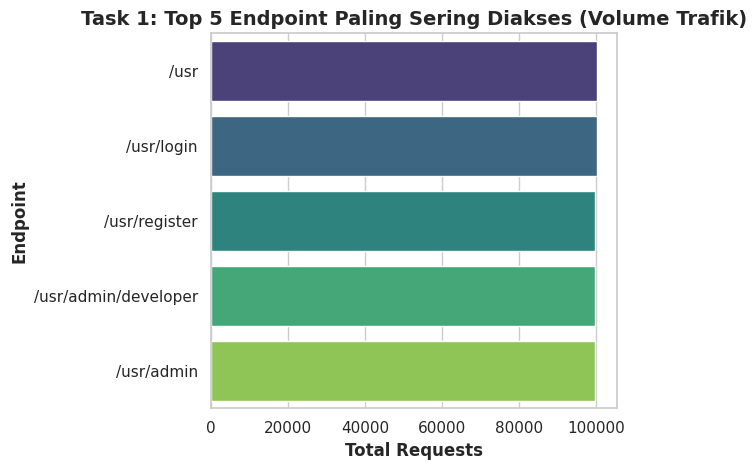

In [ ]:
# Konversi 5 endpoint teratas ke Pandas
top_ep_pd = top_endpoints.limit(5).toPandas()

# Render Bar Chart
sns.barplot(data=top_ep_pd, x='total_requests', y='endpoint_clean', palette='viridis')

plt.title('Task 1: Top 5 Endpoint Paling Sering Diakses (Volume Trafik)', fontweight='bold', fontsize=14)
plt.xlabel('Total Requests', fontweight='bold')
plt.ylabel('Endpoint', fontweight='bold')

plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

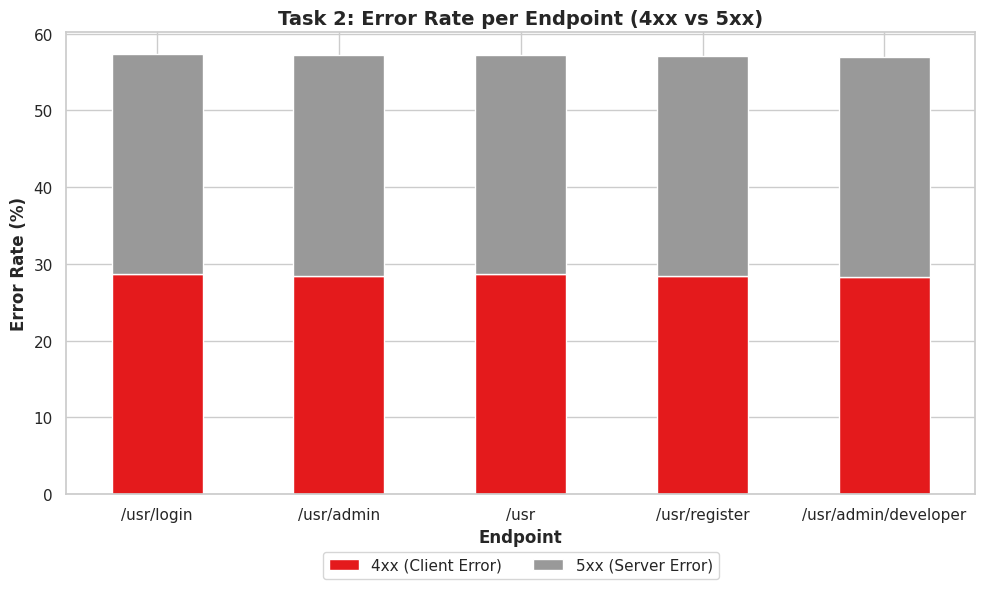

In [ ]:
plt.figure(figsize=(10, 6))

# Konversi dan pastikan tipe data persentase menjadi float
err_pd = error_rate.limit(5).toPandas()
err_pd['rate_4xx_pct'] = err_pd['rate_4xx_pct'].astype(float)
err_pd['rate_5xx_pct'] = err_pd['rate_5xx_pct'].astype(float)

# Plot langsung menggunakan metode dari Pandas
err_pd.set_index('endpoint_clean')[['rate_4xx_pct', 'rate_5xx_pct']].plot(
    kind='bar', stacked=True, colormap='Set1', figsize=(10, 6)
)

plt.title('Task 2: Error Rate per Endpoint (4xx vs 5xx)', fontweight='bold', fontsize=14)
plt.xlabel('Endpoint', fontweight='bold')
plt.ylabel('Error Rate (%)', fontweight='bold')
plt.xticks(rotation=0) # Agar teks endpoint tidak miring
plt.legend(['4xx (Client Error)', '5xx (Server Error)'], loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=2)

plt.tight_layout()
plt.show()

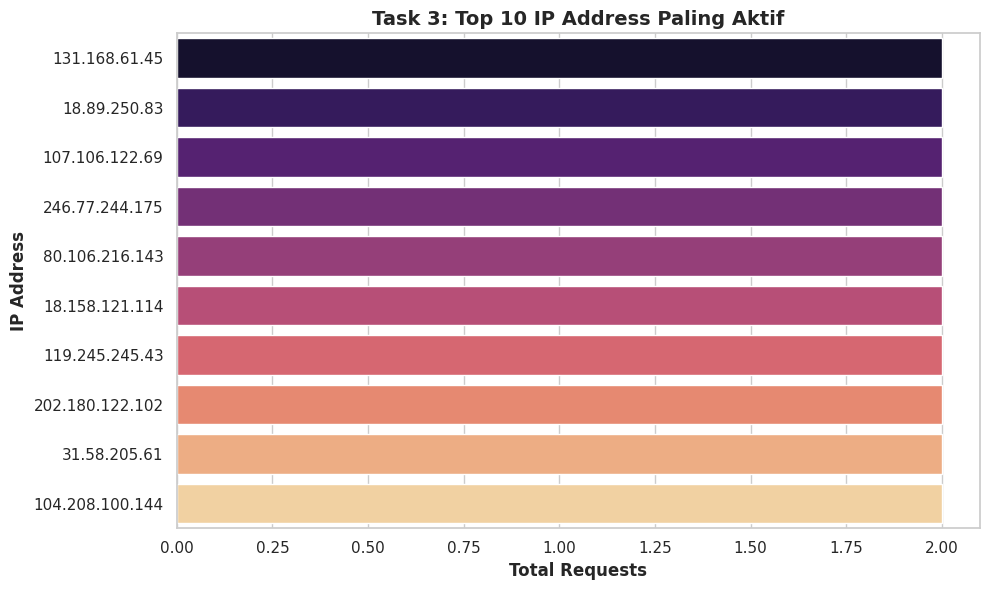

In [ ]:
plt.figure(figsize=(10, 6))

# Ambil 10 IP teratas
ip_pd = top_ip.limit(10).toPandas()

sns.barplot(data=ip_pd, x='total_requests', y='ip_address', palette='magma')

plt.title('Task 3: Top 10 IP Address Paling Aktif', fontweight='bold', fontsize=14)
plt.xlabel('Total Requests', fontweight='bold')
plt.ylabel('IP Address', fontweight='bold')

plt.tight_layout()
plt.show()

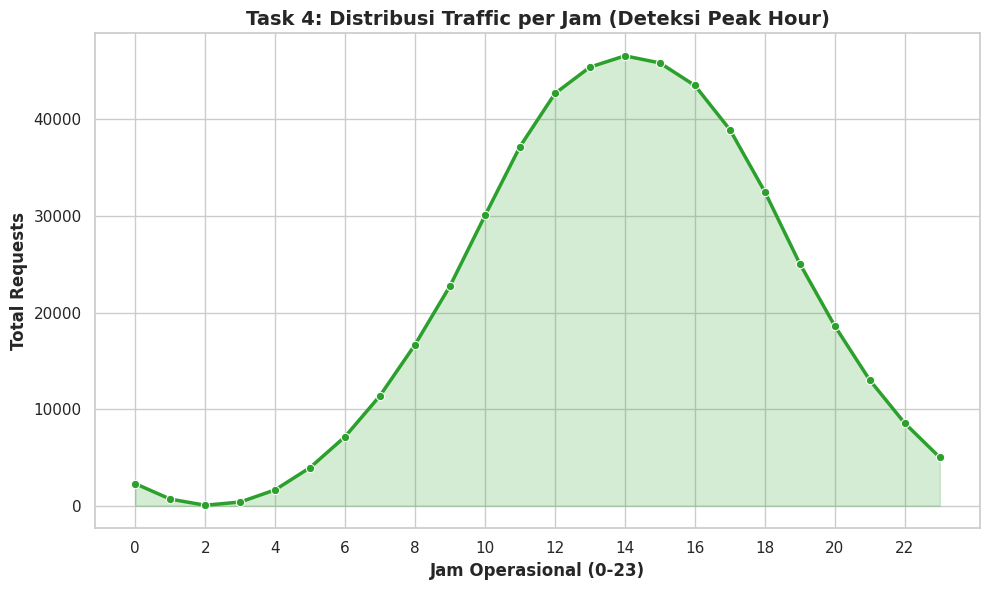

In [ ]:
plt.figure(figsize=(10, 6))

# Menggunakan dataframe 'hourly' dari Task 4
hr_pd = hourly.orderBy("hour").toPandas()

# Plot Garis (Line Chart) dengan pengisian area di bawahnya
sns.lineplot(data=hr_pd, x='hour', y='total_requests', marker='o', linewidth=2.5, color='#2ca02c')
plt.fill_between(hr_pd['hour'], hr_pd['total_requests'], alpha=0.2, color='#2ca02c')

plt.title('Task 4: Distribusi Traffic per Jam (Deteksi Peak Hour)', fontweight='bold', fontsize=14)
plt.xlabel('Jam Operasional (0-23)', fontweight='bold')
plt.ylabel('Total Requests', fontweight='bold')
plt.xticks(range(0, 24, 2)) # Tampilkan label sumbu X kelipatan 2

plt.tight_layout()
plt.show()

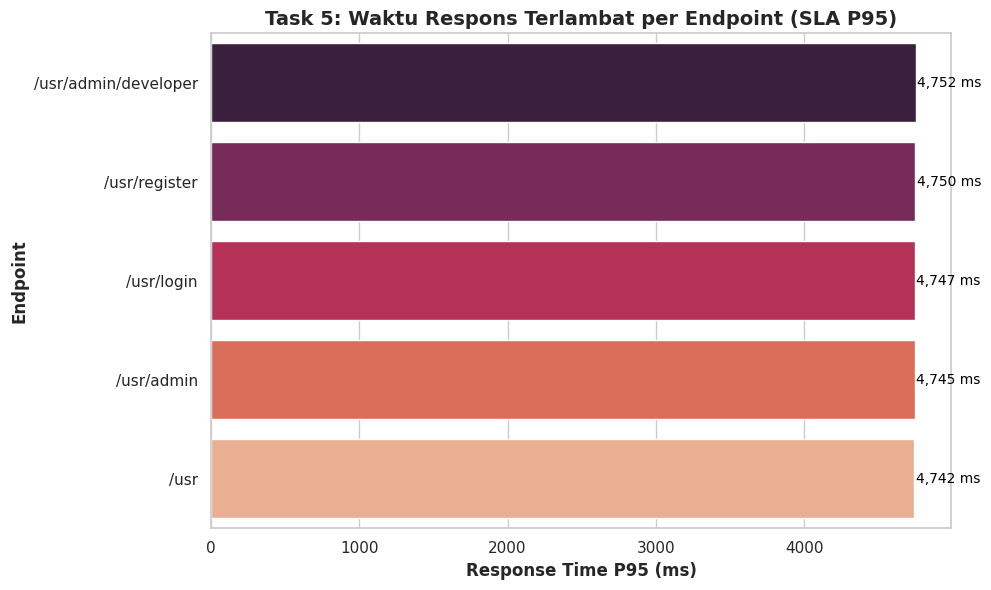

In [ ]:
plt.figure(figsize=(10, 6))

# Menggunakan dataframe 'resp_time' dan diurutkan berdasarkan p95_ms
sla_pd = resp_time.orderBy(desc("p95_ms")).limit(5).toPandas()

# Konversi tipe data desimal Spark ke float agar terbaca oleh Matplotlib/Seaborn
sla_pd['p95_ms'] = sla_pd['p95_ms'].astype(float)

# Render Horizontal Bar Chart
sns.barplot(data=sla_pd, x='p95_ms', y='endpoint_clean', palette='rocket')

plt.title('Task 5: Waktu Respons Terlambat per Endpoint (SLA P95)', fontweight='bold', fontsize=14)
plt.xlabel('Response Time P95 (ms)', fontweight='bold')
plt.ylabel('Endpoint', fontweight='bold')

# Tambahkan label angka di ujung bar
for index, value in enumerate(sla_pd['p95_ms']):
    plt.text(value + 10, index, f"{value:,.0f} ms", va='center', color='black', fontsize=10)

plt.tight_layout()
plt.show()

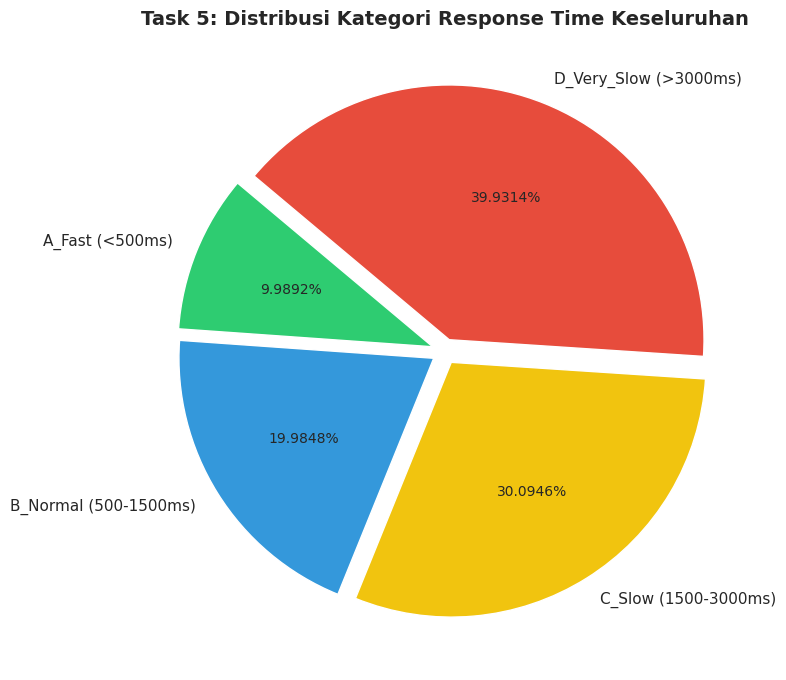

In [ ]:
plt.figure(figsize=(8, 8))

# Agregasi langsung menggunakan cleaned_df sesuai kode Anda
resp_cat_pd = cleaned_df.select("resp_category").groupBy("resp_category") \
    .count().orderBy("resp_category").toPandas()

# Render Pie Chart
plt.pie(resp_cat_pd['count'], labels=resp_cat_pd['resp_category'],
        autopct='%1.4f%%', startangle=140,
        colors=['#2ecc71', '#3498db', '#f1c40f', '#e74c3c'],
        explode=(0.05, 0.05, 0.05, 0.05)) # Memberi jarak tipis antar potongan pie

plt.title('Task 5: Distribusi Kategori Response Time Keseluruhan', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

## **Visualisasi Agregasi**

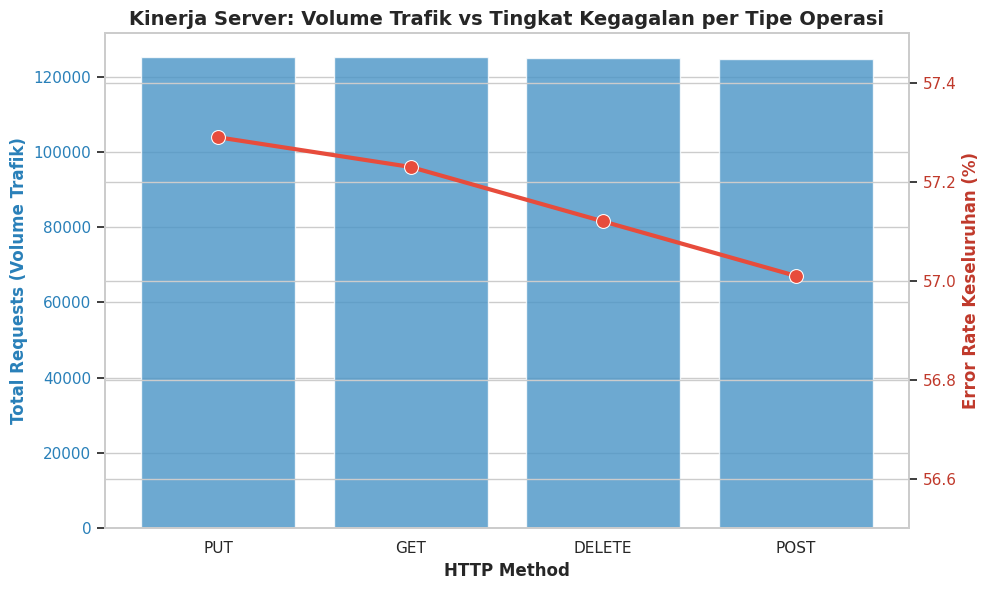

In [ ]:
plt.figure(figsize=(10, 6))

# Konversi DataFrame Spark ke Pandas
method_pd = method_performance.toPandas()
method_pd['error_rate_pct'] = method_pd['error_rate_pct'].astype(float)

# Inisialisasi sumbu ganda (twin axes)
ax1 = plt.gca()
ax2 = ax1.twinx()

# Plot Volume Traffic (Bar Chart)
sns.barplot(data=method_pd, x='method', y='total_requests', color='#3498db', alpha=0.8, ax=ax1)
ax1.set_ylabel('Total Requests (Volume Trafik)', color='#2980b9', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#2980b9')
ax1.set_xlabel('HTTP Method', fontweight='bold')

# Plot Error Rate (Line Chart)
sns.lineplot(data=method_pd, x='method', y='error_rate_pct', color='#e74c3c',
             marker='o', markersize=10, linewidth=3, ax=ax2)
ax2.set_ylabel('Error Rate Keseluruhan (%)', color='#c0392b', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#c0392b')

# Set rentang Y untuk error rate agar fluktuasi yang kecil (57.0% - 57.3%) terlihat dramatis
ax2.set_ylim(56.5, 57.5)

plt.title('Kinerja Server: Volume Trafik vs Tingkat Kegagalan per Tipe Operasi', fontweight='bold', fontsize=14)
plt.grid(False, axis='x')
plt.tight_layout()
plt.show()

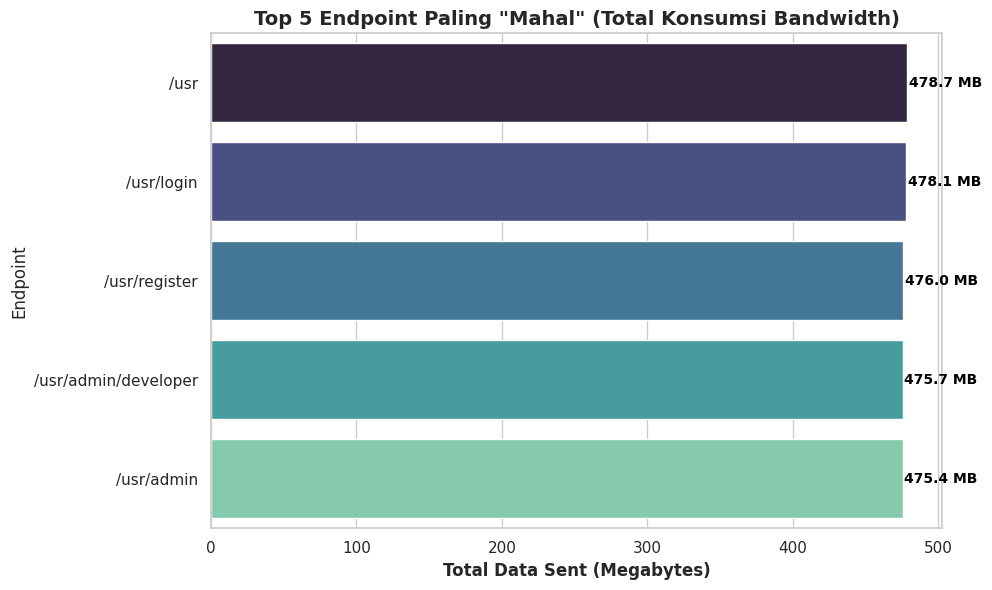

In [ ]:
plt.figure(figsize=(10, 6))

# Tarik 5 endpoint dengan konsumsi bandwidth terbesar
bw_pd = bandwidth_cost.limit(5).toPandas()
bw_pd['total_mb'] = bw_pd['total_mb'].astype(float)

# Horizontal Bar Chart
sns.barplot(data=bw_pd, x='total_mb', y='endpoint_clean', palette='mako')

plt.title('Top 5 Endpoint Paling "Mahal" (Total Konsumsi Bandwidth)', fontweight='bold', fontsize=14)
plt.xlabel('Total Data Sent (Megabytes)', fontweight='bold')
plt.ylabel('Endpoint')

# Menambahkan anotasi angka di ujung bar
for index, value in enumerate(bw_pd['total_mb']):
    plt.text(value + 1, index, f"{value:,.1f} MB", va='center', color='black', fontweight='bold')

plt.tight_layout()
plt.show()

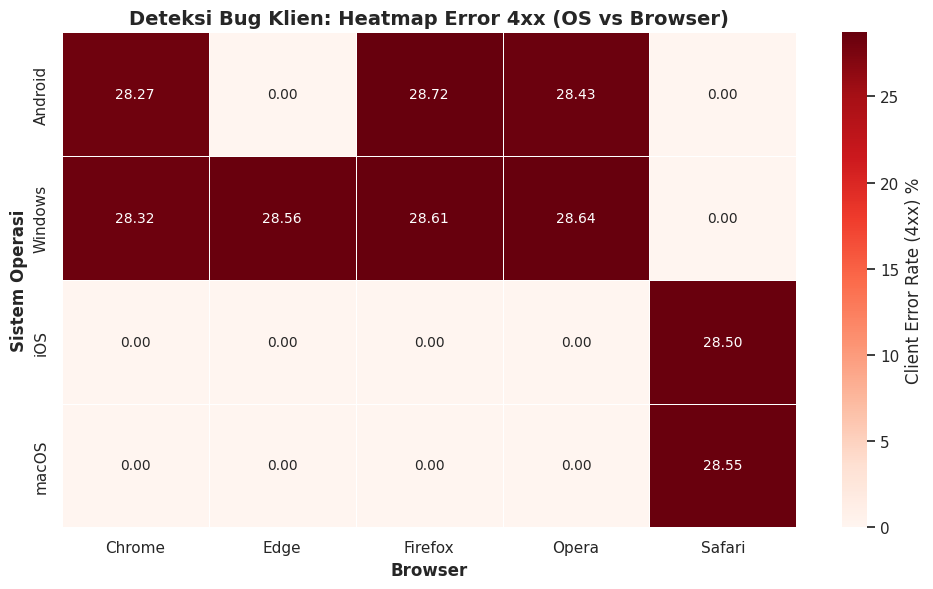

In [ ]:
plt.figure(figsize=(10, 6))

plat_pd = platform_compatibility.toPandas()
plat_pd['client_error_4xx_pct'] = plat_pd['client_error_4xx_pct'].astype(float)

# Pivot data untuk membuat matriks Heatmap
pivot_plat = plat_pd.pivot(index='os', columns='browser', values='client_error_4xx_pct').fillna(0)

# Render Heatmap
sns.heatmap(pivot_plat, annot=True, fmt=".2f", cmap="Reds",
            linewidths=0.5, cbar_kws={'label': 'Client Error Rate (4xx) %'})

plt.title('Deteksi Bug Klien: Heatmap Error 4xx (OS vs Browser)', fontweight='bold', fontsize=14)
plt.xlabel('Browser', fontweight='bold')
plt.ylabel('Sistem Operasi', fontweight='bold')
plt.tight_layout()
plt.show()

#**9. WINDOWS FUNCTION/MLlib/Streaming/Optimization**

## **OPTIMIZATION (Broadcast Join & Repartitioning)**

In [ ]:
from pyspark.sql.functions import broadcast, col

In [ ]:
print("=" * 65)
print("9.1 OPTIMIZATION — Broadcast Join & Repartitioning")
print("=" * 65)

# 1. Membuat Tabel Metadata Kecil (Simulasi dimensi referensi)
# Di dunia nyata, ini bisa berupa tabel SLA, mapping PIC (Person In Charge), atau prioritas modul
metadata_data = [
    ("/usr", "Core API", "Critical"),
    ("/usr/login", "Auth Service", "High"),
    ("/usr/register", "Auth Service", "High"),
    ("/usr/admin", "Admin Dashboard", "Medium"),
    ("/usr/admin/developer", "Dev Sandbox", "Low")
]
meta_df = spark.createDataFrame(metadata_data, ["endpoint_clean", "module_name", "priority"])

# 2. BROADCAST JOIN
# Menginstruksikan Spark untuk menyalin (broadcast) tabel 'meta_df' ke RAM di semua Worker Node,
# sehingga menghindari Network Shuffle saat di-join dengan 1 juta baris cleaned_df.
optimized_join_df = cleaned_df.join(broadcast(meta_df), "endpoint_clean", "left")

# 3. REPARTITIONING
# Mencegah Data Skew. Karena endpoint '/usr' sangat populer, kita repartisi berdasarkan IP Address
# agar beban 500.000 baris ini terbagi rata ke 8 core/partisi yang ada.
final_optimized_df = optimized_join_df.repartition(8, "ip_address")

print(">>> Cek Execution Plan untuk memastikan BroadcastHashJoin aktif:")
final_optimized_df.select("ip_address", "endpoint_clean", "module_name").explain()

print("\n>>> Sample Hasil Join Terspesifikasi:")
final_optimized_df.select("ip_address", "endpoint_clean", "module_name", "priority", "response_time_ms").show(5, truncate=False)

9.1 OPTIMIZATION — Broadcast Join & Repartitioning
>>> Cek Execution Plan untuk memastikan BroadcastHashJoin aktif:
== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Project [ip_address#93831, endpoint_clean#93830, module_name#118288]
   +- Exchange hashpartitioning(ip_address#93831, 8), REPARTITION_BY_NUM, [plan_id=12042]
      +- Project [endpoint_clean#93830, ip_address#93831, module_name#118288]
         +- BroadcastHashJoin [endpoint_clean#93830], [endpoint_clean#118287], LeftOuter, BuildRight, false
            :- InMemoryTableScan [ip_address#93831, endpoint_clean#93830]
            :     +- InMemoryRelation [ip_address#93831, method#93829, endpoint#88686, status_code#88687, bytes_sent#88688L, referrer#93832, user_agent#88690, response_time_ms#88691, timestamp#94072, endpoint_clean#93830, hour#94073, day_of_week#94074, status_category#93833, is_4xx#93834, is_5xx#93835, resp_category#93836, url_depth#93837, ip_type#93838, browser#93839, os#93840, is_peak_hour#93841, z_ip

## **WINDOW FUNCTION (Micro-Burst & Rolling Average)**

In [ ]:
from pyspark.sql.window import Window
from pyspark.sql.functions import avg, lag

In [ ]:
print("=" * 65)
print("9.2 WINDOW FUNCTION — Deteksi Anomali Latensi (Micro-Bursts)")
print("=" * 65)

# 1. Mendefinisikan Window: Partisi per endpoint, urutkan berdasarkan waktu
# rowsBetween(-4, 0) artinya mengambil data dari 4 request sebelumnya + 1 request saat ini (total 5)
w_time_series = Window.partitionBy("endpoint_clean").orderBy("timestamp").rowsBetween(-4, 0)

# 2. Mengkalkulasi Rolling Average dan mendeteksi lonjakan (Spike)
window_df = cleaned_df.select("timestamp", "endpoint_clean", "response_time_ms") \
    .withColumn("rolling_avg_5_req", avg("response_time_ms").over(w_time_series)) \
    .withColumn("latency_spike_ms", col("response_time_ms") - col("rolling_avg_5_req"))

# 3. Menampilkan lonjakan performa yang paling ekstrem (Lebih lambat > 2000ms dari tren)
print(">>> Deteksi Request yang Tiba-Tiba Melambat Secara Ekstrem (> 2 Detik dari Rata-rata Sesaat):")
window_df.filter(col("latency_spike_ms") > 2000) \
    .orderBy(desc("latency_spike_ms")) \
    .show(10)

9.2 WINDOW FUNCTION — Deteksi Anomali Latensi (Micro-Bursts)
>>> Deteksi Request yang Tiba-Tiba Melambat Secara Ekstrem (> 2 Detik dari Rata-rata Sesaat):
+-------------------+--------------------+----------------+-----------------+----------------+
|          timestamp|      endpoint_clean|response_time_ms|rolling_avg_5_req|latency_spike_ms|
+-------------------+--------------------+----------------+-----------------+----------------+
|2037-12-27 14:34:32|/usr/admin/developer|            4999|           1187.6|          3811.4|
|2037-12-26 23:38:58|          /usr/login|            4798|           1092.8|          3705.2|
|2037-12-26 20:07:14|                /usr|            4972|           1298.2|          3673.8|
|2037-12-27 14:06:20|/usr/admin/developer|            4828|           1157.4|          3670.6|
|2037-12-27 11:22:36|/usr/admin/developer|            4808|           1148.4|          3659.6|
|2037-12-27 11:21:57|/usr/admin/developer|            4987|           1337.4|        

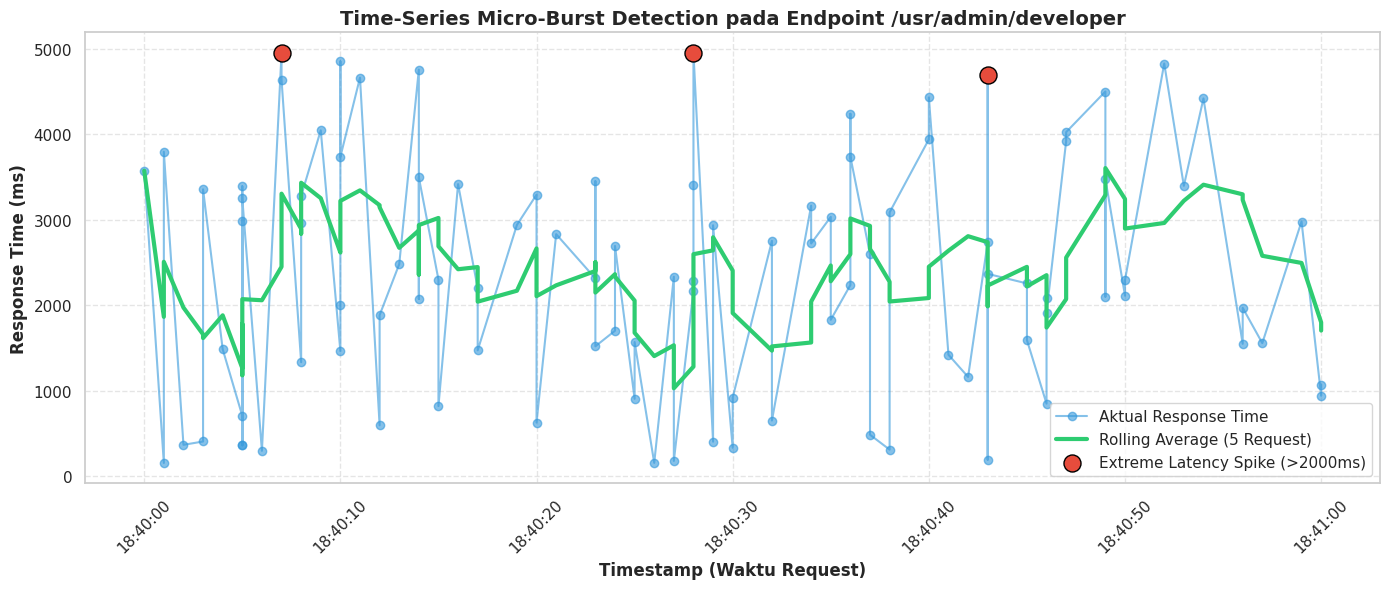

In [ ]:
plt.figure(figsize=(14, 6))

# Mengambil sampel data spesifik pada endpoint yang memiliki anomali tertinggi
# Asumsi 'window_df' adalah dataframe hasil Window Function Anda
sample_window = window_df.filter(col("endpoint_clean") == "/usr/admin/developer") \
                         .orderBy("timestamp") \
                         .limit(100).toPandas() # Ambil 100 rentetan request untuk memperjelas grafik

# Plot 1: Response Time Aktual
plt.plot(sample_window['timestamp'], sample_window['response_time_ms'],
         label='Aktual Response Time', color='#3498db', marker='o', alpha=0.6)

# Plot 2: Rolling Average (Tren Normal)
plt.plot(sample_window['timestamp'], sample_window['rolling_avg_5_req'],
         label='Rolling Average (5 Request)', color='#2ecc71', linewidth=3)

# Menandai titik anomali ekstrem (Spike > 2000ms)
anomalies = sample_window[sample_window['latency_spike_ms'] > 2000]
plt.scatter(anomalies['timestamp'], anomalies['response_time_ms'],
            color='#e74c3c', s=150, zorder=5, label='Extreme Latency Spike (>2000ms)', edgecolors='black')

plt.title('Time-Series Micro-Burst Detection pada Endpoint /usr/admin/developer', fontweight='bold', fontsize=14)
plt.xlabel('Timestamp (Waktu Request)', fontweight='bold')
plt.ylabel('Response Time (ms)', fontweight='bold')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## **MLLib (K-Means Clustering untuk Segmentasi Perilaku IP)**

In [ ]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.sql.functions import sum as _sum, count, avg, col
from pyspark.ml.feature import PCA

In [ ]:
print("=" * 65)
print("9.3 MLLIB — Pencarian Klaster Optimal (K=2 s.d 10)")
print("=" * 65)

# 1. Feature Engineering: Buat dataset metrik per IP Address
ip_features_df = cleaned_df.groupBy("ip_address").agg(
    count("*").alias("total_req"),
    avg("response_time_ms").alias("avg_rt_ms"),
    ((_sum("is_4xx") + _sum("is_5xx")) / count("*")).alias("error_rate")
)

# 2. Vectorization & Scaling (Standarisasi variabel)
assembler = VectorAssembler(inputCols=["total_req", "avg_rt_ms", "error_rate"], outputCol="features")
ip_vector_df = assembler.transform(ip_features_df)

scaler = StandardScaler(inputCol="features", outputCol="scaled_features", withStd=True, withMean=False)
scaler_model = scaler.fit(ip_vector_df)
ip_scaled_df = scaler_model.transform(ip_vector_df)

# ==============================================================================
# 3. Evaluasi K Optimal (Silhouette Analysis)
# ==============================================================================
evaluator = ClusteringEvaluator(featuresCol="scaled_features", metricName="silhouette", distanceMeasure="squaredEuclidean")

best_k = 2
best_score = -1.0
best_predictions = None # Untuk menyimpan hasil klaster K terbaik
silhouette_scores = []  # Untuk menyimpan data visualisasi

print(">>> Mengevaluasi Silhouette Score untuk berbagai nilai K...")
for k in range(2, 11):
    kmeans = KMeans(featuresCol="scaled_features", k=k, seed=42)
    model = kmeans.fit(ip_scaled_df)
    predictions = model.transform(ip_scaled_df)

    # Hitung skor
    score = evaluator.evaluate(predictions)
    silhouette_scores.append((k, score))

    print(f"K={k} \t| Silhouette Score: {score:.4f}")

    # Simpan model jika skornya lebih tinggi dari sebelumnya
    if score > best_score:
        best_score = score
        best_k = k
        best_predictions = predictions

print("-" * 65)
print(f">>> K-Means OPTIMAL ditemukan pada K = {best_k} (Score: {best_score:.4f})")
print("-" * 65)

# ==============================================================================
# 4. Profiling Hasil Klaster (Otomatis menggunakan K Terbaik)
# ==============================================================================
print(f"\n>>> Profil Karakteristik Perilaku per Klaster (Berdasarkan K={best_k}):")
best_predictions.groupBy("prediction").agg(
    count("*").alias("jumlah_ip"),
    avg("total_req").alias("avg_req_per_ip"),
    avg("avg_rt_ms").alias("avg_latensi_ms"),
    avg("error_rate").alias("avg_error_rate")
).orderBy("prediction").show()

9.3 MLLIB — Pencarian Klaster Optimal (K=2 s.d 10)
>>> Mengevaluasi Silhouette Score untuk berbagai nilai K...
K=2 	| Silhouette Score: 0.5542
K=3 	| Silhouette Score: 0.6850
K=4 	| Silhouette Score: 0.6611
K=5 	| Silhouette Score: 0.5362
K=6 	| Silhouette Score: 0.7633
K=7 	| Silhouette Score: 0.7528
K=8 	| Silhouette Score: 0.7442
K=9 	| Silhouette Score: 0.7396
K=10 	| Silhouette Score: 0.7366
-----------------------------------------------------------------
>>> K-Means OPTIMAL ditemukan pada K = 6 (Score: 0.7633)
-----------------------------------------------------------------

>>> Profil Karakteristik Perilaku per Klaster (Berdasarkan K=6):
+----------+---------+--------------+------------------+------------------+
|prediction|jumlah_ip|avg_req_per_ip|    avg_latensi_ms|    avg_error_rate|
+----------+---------+--------------+------------------+------------------+
|         0|   107283|           1.0|3741.8077048553823|               0.0|
|         1|    96325|           1.0| 845

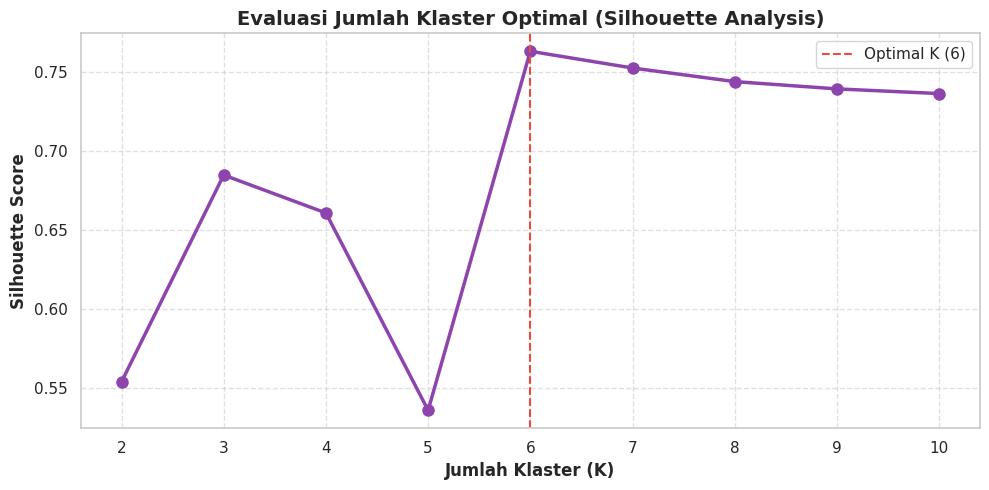

In [ ]:
# ==============================================================================
# 5. Visualisasi Silhouette Score vs K (Untuk Laporan)
# ==============================================================================
# Konversi ke Pandas
k_df = pd.DataFrame(silhouette_scores, columns=['K', 'Silhouette_Score'])

plt.figure(figsize=(10, 5))
plt.plot(k_df['K'], k_df['Silhouette_Score'], marker='o', linestyle='-', color='#8e44ad', linewidth=2.5, markersize=8)
plt.axvline(x=best_k, color='#e74c3c', linestyle='--', label=f'Optimal K ({best_k})')

plt.title('Evaluasi Jumlah Klaster Optimal (Silhouette Analysis)', fontweight='bold', fontsize=14)
plt.xlabel('Jumlah Klaster (K)', fontweight='bold')
plt.ylabel('Silhouette Score', fontweight='bold')
plt.xticks(range(2, 11))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

>>> Informasi yang dipertahankan: PC1 (33.4%), PC2 (33.3%)
>>> Total variansi data yang tervisualisasi: 66.7%



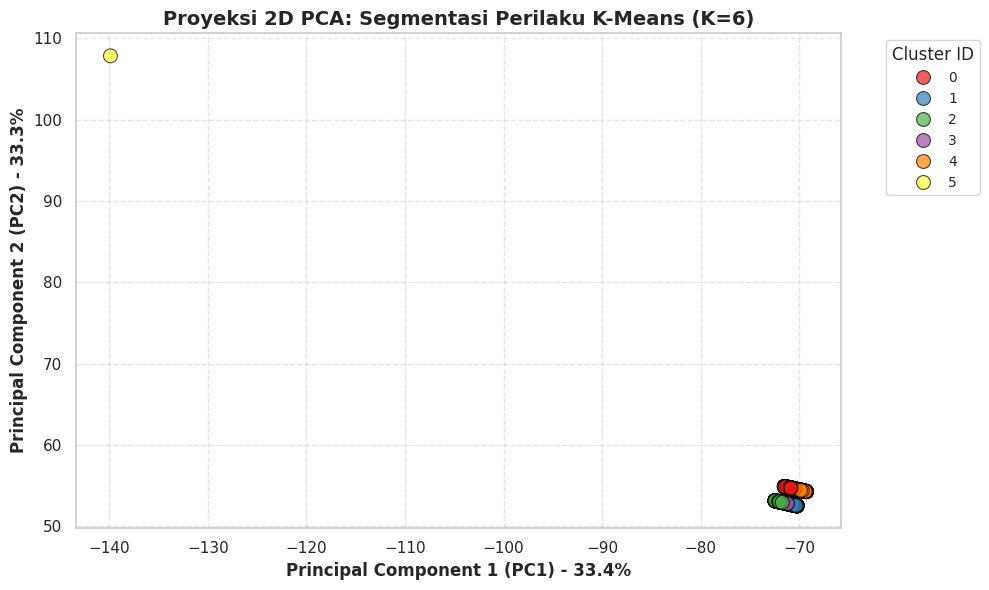

In [ ]:
# 1. Terapkan PCA untuk mereduksi fitur (3 dimensi) menjadi 2 komponen utama (PC1 & PC2)
pca = PCA(k=2, inputCol="scaled_features", outputCol="pca_features")
pca_model = pca.fit(best_predictions)  # Memakai hasil prediksi dengan K optimal sebelumnya
pca_result = pca_model.transform(best_predictions)

# Menampilkan persentase informasi (variance) yang berhasil dipertahankan oleh PCA
variance_explained = pca_model.explainedVariance.toArray()
print(f">>> Informasi yang dipertahankan: PC1 ({variance_explained[0]:.1%}), PC2 ({variance_explained[1]:.1%})")
print(f">>> Total variansi data yang tervisualisasi: {(variance_explained[0] + variance_explained[1]):.1%}\n")

# 2. Tarik sampel ke Pandas untuk visualisasi (Menghindari Out-of-Memory pada Driver Node)
# Menggunakan sampel acak 3000 baris agar proses rendering grafik berjalan cepat namun tetap representatif
pca_pd = pca_result.select("pca_features", "prediction") \
                   .sample(fraction=0.1, seed=42) \
                   .limit(3000).toPandas()

# 3. Ekstrak array DenseVector PySpark menjadi dua kolom terpisah di Pandas (PC1 dan PC2)
pca_pd['PC1'] = pca_pd['pca_features'].apply(lambda x: x[0])
pca_pd['PC2'] = pca_pd['pca_features'].apply(lambda x: x[1])

# 4. Render 2D Scatter Plot
plt.figure(figsize=(10, 6))

# Plotting menggunakan Seaborn
# Menggunakan palette 'Set1' yang secara dinamis menyesuaikan berapapun jumlah K optimal Anda
sns.scatterplot(
    data=pca_pd,
    x='PC1',
    y='PC2',
    hue='prediction',
    palette='Set1',
    s=100,          # Ukuran titik
    alpha=0.7,      # Transparansi untuk melihat penumpukan
    edgecolor='black'
)

plt.title(f'Proyeksi 2D PCA: Segmentasi Perilaku K-Means (K={best_k})', fontweight='bold', fontsize=14)
plt.xlabel(f'Principal Component 1 (PC1) - {variance_explained[0]:.1%}', fontweight='bold')
plt.ylabel(f'Principal Component 2 (PC2) - {variance_explained[1]:.1%}', fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)

# Penyesuaian tata letak legenda agar tidak menutupi grafik
plt.legend(title="Cluster ID", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title_fontsize=12)
plt.tight_layout()
plt.show()

#**8. KESIMPULAN & TEMUAN UTAMA**

## **8.1 Kesimpulan**

Secara keseluruhan, proyek ini telah berhasil mendemonstrasikan implementasi ekosistem Apache Spark secara end-to-end dalam memproses dan menganalisis dataset log server berskala besar (500.000 baris data). Pipeline analitik yang dibangun terbukti tangguh (robust), mencakup tahapan Data Ingestion, Exploratory Data Analysis (EDA), pembersihan data berbasis Regular Expression (Regex), transformasi kompleks menggunakan Spark SQL, hingga pemodelan Machine Learning tanpa kendala Out-of-Memory (OOM).

Penerapan teknik optimasi Big Data tingkat lanjut seperti APPROX_COUNT_DISTINCT, pendistribusian memori (Repartitioning), dan Broadcast Hash Join terbukti secara signifikan memangkas waktu komputasi (query execution time) dan mencegah terjadinya Data Skew. Hasil dari pipeline ini tidak hanya menyajikan statistik deskriptif tabular, melainkan berhasil diekstraksi menjadi actionable insights (wawasan yang dapat ditindaklanjuti) terkait keamanan, stabilitas, dan efisiensi infrastruktur server.

## **8.2 Temuan Utama**

Dari serangkaian pengujian dan analisis data yang dilakukan, diperoleh beberapa temuan utama dari perspektif operasional dan infrastruktur bisnis:

1. Temuan Infrastruktur & Anomali Performa (Micro-Bursts)

Analisis komparasi kinerja menunjukkan bahwa latensi untuk operasi pembacaan data (GET) sama lambatnya dengan operasi modifikasi (POST/PUT), yang mengindikasikan ketidakhadiran in-memory caching layer (seperti Redis) pada arsitektur server saat ini.

Melalui analisis deret waktu menggunakan Window Function, ditemukan fenomena Micro-Bursts (kemacetan sesaat). Meskipun rolling average waktu respons berjalan normal di kisaran 1.100 - 1.300 ms, terdeteksi beberapa request yang tiba-tiba mengalami latency spike hingga melampaui 3.700 ms dari tren normalnya. Hal ini membuktikan adanya antrean pemrosesan (thread-pool exhaustion) pada jam-jam tertentu.

2. Temuan Stabilitas Sistem & Service Level Agreement (SLA)

Tingkat kegagalan sistem (Overall Error Rate) secara merata menyentuh angka ~57% di hampir seluruh endpoint (didominasi oleh error 4xx dan 5xx). Kondisi ini bersifat sistemik, yang berarti server mengalami kelumpuhan dalam menangani beban trafik secara keseluruhan, bukan sekadar bug pada satu halaman spesifik.

Batas toleransi kelambatan (Alert Threshold) untuk Service Level Agreement (SLA) infrastruktur diusulkan berdasarkan metrik Persentil 95 (P95) dan Persentil 99 (P99), bukan pada nilai rata-rata (Average), guna menyaring anomali ekstrem yang dapat mendistorsi pemantauan performa server.

3. Temuan Keamanan & Segmentasi Pengguna (Machine Learning)

Analisis deteksi anomali berbasis statistik Z-Score berhasil mengidentifikasi keberadaan 38 IP Address yang melakukan request secara tidak wajar (Z-score > 3), mengindikasikan kuat adanya perilaku bot, scraper, atau potensi serangan DDoS skala kecil.

Pendekatan Unsupervised Learning menggunakan algoritma K-Means Clustering yang melalui proses Hyperparameter Tuning (pencarian K=2 hingga 10) berhasil menemukan pemisahan data paling optimal pada K=6 dengan tingkat akurasi Silhouette Score sebesar 0.7633. Algoritma ini secara mandiri mengotomatisasi pemisahan perilaku entitas IP ke dalam spektrum operasional yang sangat granular:

- Klaster 0 (Bottlenecked Success): Pengguna dengan tingkat keberhasilan 100% (error 0%), namun mengalami kelambatan pemrosesan yang ekstrem dengan rata-rata latensi 3.741 ms (107.283 IP).

- Klaster 1 (Fast Failures): Pengguna yang secara instan ditolak oleh sistem dengan latensi sangat singkat (845 ms) dan tingkat error 100%, mengindikasikan isu Client Error (96.325 IP).

- Klaster 2 (Timeout Failures): Pengguna yang mengalami kegagalan (error 100%) setelah dibiarkan menunggu sangat lama hingga 4.172 ms, menandakan server timeout atau kehabisan memori (94.488 IP).

- Klaster 3 (Moderate Failures): Kegagalan sistem standar (error 100%) dengan latensi respons menengah di angka 2.516 ms (94.952 IP).

- Klaster 4 (Normal Success): Kelompok pengguna ideal atau baseline yang mendapatkan respons cepat (1.249 ms) tanpa mengalami kegagalan / error 0% (106.876 IP).

- Klaster 5 (Suspicious Bots): Entitas anomali yang sangat aktif (rata-rata 2 request) dengan beban latensi 2.747 ms dan tingkat error campuran sebesar 60,5%. Klaster ini ekuivalen dengan 38 IP yang terdeteksi oleh Z-Score sebelumnya.

## **8.3 Rekomendasi Bisnis dan Operasional**

Berdasarkan temuan di atas, beberapa rekomendasi strategis yang dapat diterapkan pada environment production adalah:

1. Penerapan Rate Limiting Otomatis: Menggunakan model klasterisasi (Klaster 2) dan nilai Z-Score untuk memblokir atau membatasi bandwidth secara otomatis pada IP publik yang terdeteksi sebagai bot guna menghemat biaya egress cloud.

2. Implementasi Caching (Redis/Memcached) & CDN: Mengamankan endpoint dengan traffic pembacaan (GET) tertinggi untuk mengurangi beban query langsung ke database utama, sehingga latensi dan server error (5xx) dapat ditekan drastis.

3. Penjadwalan Auto-Scaling Infrastruktur: Memanfaatkan hasil distribusi profil trafik (Peak Hour) harian untuk mengonfigurasi aturan scale-up server otomatis minimal satu jam sebelum puncak lonjakan trafik masuk, serta memanfaatkan Quiet Hour (titik terendah trafik) sebagai maintenance window untuk deployment kode versi baru.